# ***0. IMPORTING LIBRARIES AND UPLOAD DATASET***

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


df = pd.read_csv('/content/drive/MyDrive/DataSets/household_power_consumption.txt', sep=';')

In [ ]:
df.head(20)

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0
5,16/12/2006,17:29:00,3.520,0.522,235.020,15.000,0.000,2.000,17.0
6,16/12/2006,17:30:00,3.702,0.520,235.090,15.800,0.000,1.000,17.0
7,16/12/2006,17:31:00,3.700,0.520,235.220,15.800,0.000,1.000,17.0
8,16/12/2006,17:32:00,3.668,0.510,233.990,15.800,0.000,1.000,17.0
9,16/12/2006,17:33:00,3.662,0.510,233.860,15.800,0.000,2.000,16.0


# ***1. EDA***

In [ ]:
df.shape

(2075259, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    object 
 3   Global_reactive_power  object 
 4   Voltage                object 
 5   Global_intensity       object 
 6   Sub_metering_1         object 
 7   Sub_metering_2         object 
 8   Sub_metering_3         float64
dtypes: float64(1), object(8)
memory usage: 142.5+ MB


## **1.1 Cleaning missing values**

In [ ]:
df.isnull().sum()*100/len(df)

,0
Date,0.000000
Time,0.000000
Global_active_power,0.000000
Global_reactive_power,0.000000
Voltage,0.000000
Global_intensity,0.000000
Sub_metering_1,0.000000
Sub_metering_2,0.000000
Sub_metering_3,1.251844


In [ ]:
df[df['Sub_metering_3'].isnull()].head(5)

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
6839,21/12/2006,11:23:00,?,?,?,?,?,?,NaN
6840,21/12/2006,11:24:00,?,?,?,?,?,?,NaN
19724,30/12/2006,10:08:00,?,?,?,?,?,?,NaN
19725,30/12/2006,10:09:00,?,?,?,?,?,?,NaN
41832,14/1/2007,18:36:00,?,?,?,?,?,?,NaN


In [ ]:
df=df.replace('?',np.nan)
df.isnull().sum()*100/len(df)

,0
Date,0.000000
Time,0.000000
Global_active_power,1.251844
Global_reactive_power,1.251844
Voltage,1.251844
Global_intensity,1.251844
Sub_metering_1,1.251844
Sub_metering_2,1.251844
Sub_metering_3,1.251844


In [ ]:
df[df['Sub_metering_2'].isnull()].head(5)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
6839,21/12/2006,11:23:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6840,21/12/2006,11:24:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19724,30/12/2006,10:08:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19725,30/12/2006,10:09:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
41832,14/1/2007,18:36:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df['datetime']=pd.to_datetime(df['Date']+' '+df['Time'])
df=df.set_index('datetime')
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
2006-12-16 17:25:00,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2006-12-16 17:26:00,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
2006-12-16 17:27:00,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
2006-12-16 17:28:00,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [ ]:
df.columns


Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')

In [ ]:
for i in ['Global_active_power', 'Global_reactive_power','Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2']:
  df[i]=df[i].astype(float)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2075259 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 158.3+ MB


In [ ]:
for i in df.columns:
  print(f'column {i} has {df[i].nunique()} unique values')
  print('****************************************************')

column Date has 1442 unique values
****************************************************
column Time has 1440 unique values
****************************************************
column Global_active_power has 4186 unique values
****************************************************
column Global_reactive_power has 532 unique values
****************************************************
column Voltage has 2837 unique values
****************************************************
column Global_intensity has 221 unique values
****************************************************
column Sub_metering_1 has 88 unique values
****************************************************
column Sub_metering_2 has 81 unique values
****************************************************
column Sub_metering_3 has 32 unique values
****************************************************


In [ ]:
pd.options.display.float_format = '{:.2f}'.format
df.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2049280.00,2049280.00,2049280.00,2049280.00,2049280.00,2049280.00,2049280.00
mean,1.09,0.12,240.84,4.63,1.12,1.30,6.46
std,1.06,0.11,3.24,4.44,6.15,5.82,8.44
min,0.08,0.00,223.20,0.20,0.00,0.00,0.00
25%,0.31,0.05,238.99,1.40,0.00,0.00,0.00
50%,0.60,0.10,241.01,2.60,0.00,0.00,1.00
75%,1.53,0.19,242.89,6.40,0.00,1.00,17.00
max,11.12,1.39,254.15,48.40,88.00,80.00,31.00


In [ ]:
pd.DataFrame(df[df['Sub_metering_2'].isnull()].index.date).value_counts().sort_index()/60

,count
0,
2006-12-21,0.03
2006-12-30,0.03
2007-01-14,0.02
2007-01-28,0.02
2007-02-22,0.03
...,...
2010-09-25,20.07
2010-09-26,24.00
2010-09-27,24.00


**<font size="5">
<font color="#4285F4">
from data in above cell we conclude that there is big missing consecutive data & there is a small one so I decided to :\
1- for small missing periods I'll use interpolation\
2- for big missing periods I'll use weekly Imputation\
3- for missing in 2010 i'll drop them to prevent data leakage because 2010 will be my test set
</font>
</font>**

In [ ]:
df_bef2010=df[df.index.year < 2010].copy()
df2010=df[df.index.year == 2010].copy()

In [ ]:
print(df_bef2010.isnull().sum())
print(df2010.isnull().sum())

Date                        0
Time                        0
Global_active_power      8350
Global_reactive_power    8350
Voltage                  8350
Global_intensity         8350
Sub_metering_1           8350
Sub_metering_2           8350
Sub_metering_3           8350
dtype: int64
Date                         0
Time                         0
Global_active_power      17629
Global_reactive_power    17629
Voltage                  17629
Global_intensity         17629
Sub_metering_1           17629
Sub_metering_2           17629
Sub_metering_3           17629
dtype: int64


In [ ]:
df2010=df2010.dropna()
df2010.isnull().sum()

,0
Date,0
Time,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,0


In [ ]:
df_bef2010 = df_bef2010.interpolate(method='time', limit=180)
df_bef2010.isnull().sum()

,0
Date,0
Time,0
Global_active_power,7379
Global_reactive_power,7379
Voltage,7379
Global_intensity,7379
Sub_metering_1,7379
Sub_metering_2,7379
Sub_metering_3,7379


In [ ]:
for col in df_bef2010.columns:


    missing_idx = df_bef2010[df_bef2010[col].isna()].index

    for ts in missing_idx:
        prev_week = ts - pd.DateOffset(weeks=1)

        if prev_week in df_bef2010.index:
            df_bef2010.loc[ts, col] = df_bef2010.loc[prev_week, col]


df_bef2010.isnull().sum()

,0
Date,0
Time,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,0


In [ ]:
df_clean = pd.concat([df_bef2010, df2010]).sort_index()
df_clean.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.22,0.42,234.84,18.40,0.00,1.00,17.00
2006-12-16 17:25:00,16/12/2006,17:25:00,5.36,0.44,233.63,23.00,0.00,1.00,16.00
2006-12-16 17:26:00,16/12/2006,17:26:00,5.37,0.50,233.29,23.00,0.00,2.00,17.00
2006-12-16 17:27:00,16/12/2006,17:27:00,5.39,0.50,233.74,23.00,0.00,1.00,17.00
2006-12-16 17:28:00,16/12/2006,17:28:00,3.67,0.53,235.68,15.80,0.00,1.00,17.00


In [ ]:
df_clean.isnull().sum()

,0
Date,0
Time,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,0


In [ ]:
for i in df_clean.columns:
  print(f'column {i} has {df_clean[i].nunique()} unique values')
  print('****************************************************')

column Date has 1435 unique values
****************************************************
column Time has 1440 unique values
****************************************************
column Global_active_power has 5129 unique values
****************************************************
column Global_reactive_power has 1411 unique values
****************************************************
column Voltage has 3782 unique values
****************************************************
column Global_intensity has 1115 unique values
****************************************************
column Sub_metering_1 has 93 unique values
****************************************************
column Sub_metering_2 has 451 unique values
****************************************************
column Sub_metering_3 has 576 unique values
****************************************************


In [ ]:
df=df_clean.copy()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2057630 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 157.0+ MB


In [ ]:
pd.options.display.float_format = '{:.2f}'.format
df.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2057630.00,2057630.00,2057630.00,2057630.00,2057630.00,2057630.00,2057630.00
mean,1.09,0.12,240.84,4.63,1.13,1.30,6.46
std,1.06,0.11,3.24,4.44,6.16,5.82,8.44
min,0.08,0.00,223.20,0.20,0.00,0.00,0.00
25%,0.31,0.05,238.99,1.40,0.00,0.00,0.00
50%,0.60,0.10,241.01,2.60,0.00,0.00,1.00
75%,1.53,0.19,242.88,6.40,0.00,1.00,17.00
max,11.12,1.39,254.15,48.40,88.00,80.00,31.00


In [ ]:
df.drop(['Date','Time'],axis=1, inplace =True)

In [ ]:
df=df[['Global_reactive_power','Voltage','Global_intensity','Sub_metering_1','Sub_metering_2','Sub_metering_3','Global_active_power']]
df.head()

,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Global_active_power
datetime,,,,,,,
2006-12-16 17:24:00,0.42,234.84,18.40,0.00,1.00,17.00,4.22
2006-12-16 17:25:00,0.44,233.63,23.00,0.00,1.00,16.00,5.36
2006-12-16 17:26:00,0.50,233.29,23.00,0.00,2.00,17.00,5.37
2006-12-16 17:27:00,0.50,233.74,23.00,0.00,1.00,17.00,5.39
2006-12-16 17:28:00,0.53,235.68,15.80,0.00,1.00,17.00,3.67


## 1.2 Data Aggregation: Daily vs Hourly

### 1.2.1 Daily

In [ ]:
df_daily = df.resample('D').mean()
df_daily = df_daily.dropna()

df_daily['month'] = df_daily.index.month
df_daily['day_of_week'] = df_daily.index.dayofweek
df_daily['is_weekend'] = df_daily['day_of_week'].isin([5, 6]).astype(int)

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df_daily['season'] = df_daily['month'].apply(get_season)

df_daily.head()

,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Global_active_power,month,day_of_week,is_weekend,season
datetime,,,,,,,,,,,
2006-12-16,0.09,236.24,13.08,0.00,1.38,12.44,3.05,12,5,1,Winter
2006-12-17,0.16,240.09,10.00,1.41,2.91,9.26,2.35,12,6,1,Winter
2006-12-18,0.11,241.23,6.42,0.74,1.82,9.73,1.53,12,0,0,Winter
2006-12-19,0.10,242.00,4.93,0.58,5.28,4.30,1.16,12,1,0,Winter
2006-12-20,0.11,242.31,6.47,0.00,1.84,9.77,1.55,12,2,0,Winter


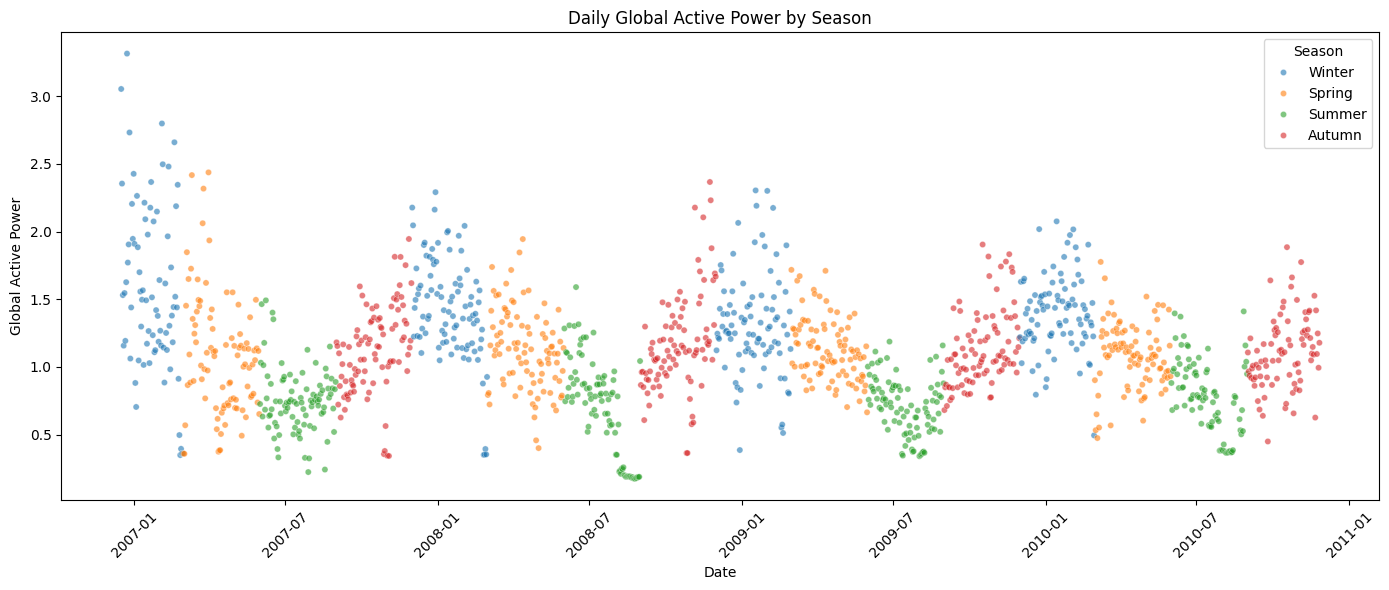

In [ ]:
plt.figure(figsize=(14,6))

sns.scatterplot(
    data=df_daily,
    x=df_daily.index,
    y='Global_active_power',
    hue='season',
    alpha=0.6,
    s=20
)

plt.title('Daily Global Active Power by Season')
plt.xlabel('Date')
plt.ylabel('Global Active Power')
plt.xticks(rotation=45)
plt.legend(title='Season')
plt.tight_layout()
plt.show()

**<font size="5">
<font color="#4285F4">
from this scatterplot we observe that there is seasonal pattern needs to be considered in our model
</font>
</font>**

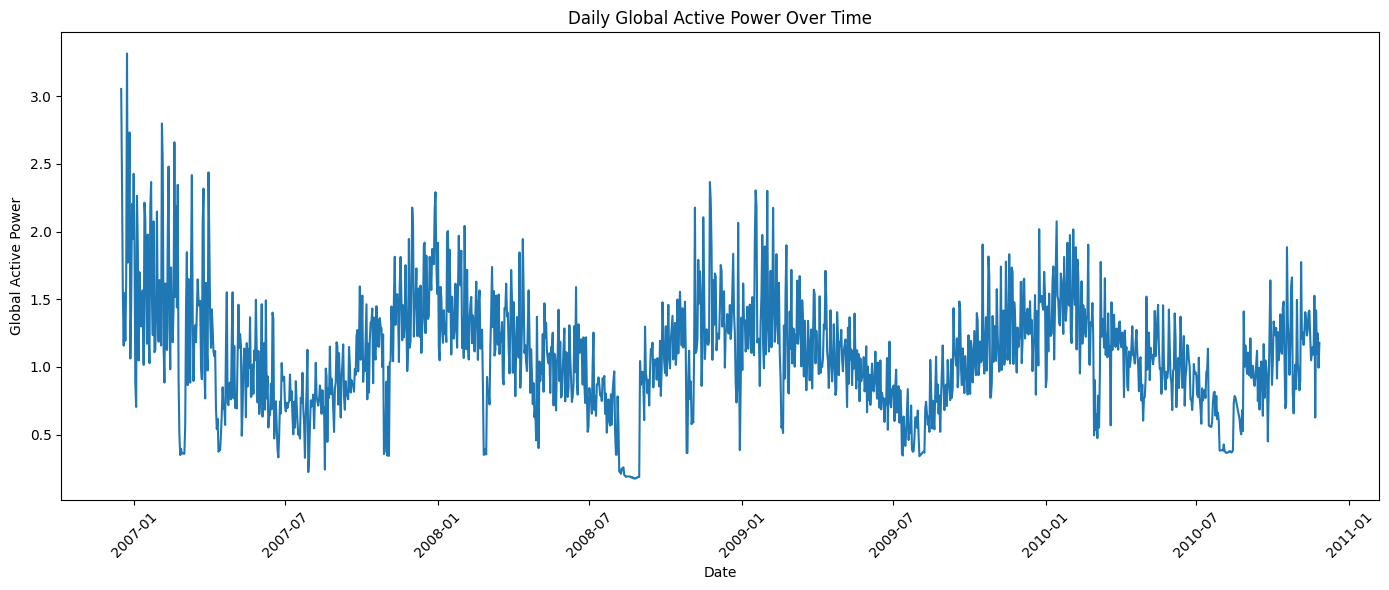

In [ ]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=df_daily,
    x=df_daily.index,
    y='Global_active_power'
)

plt.title('Daily Global Active Power Over Time')
plt.xlabel('Date')
plt.ylabel('Global Active Power')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

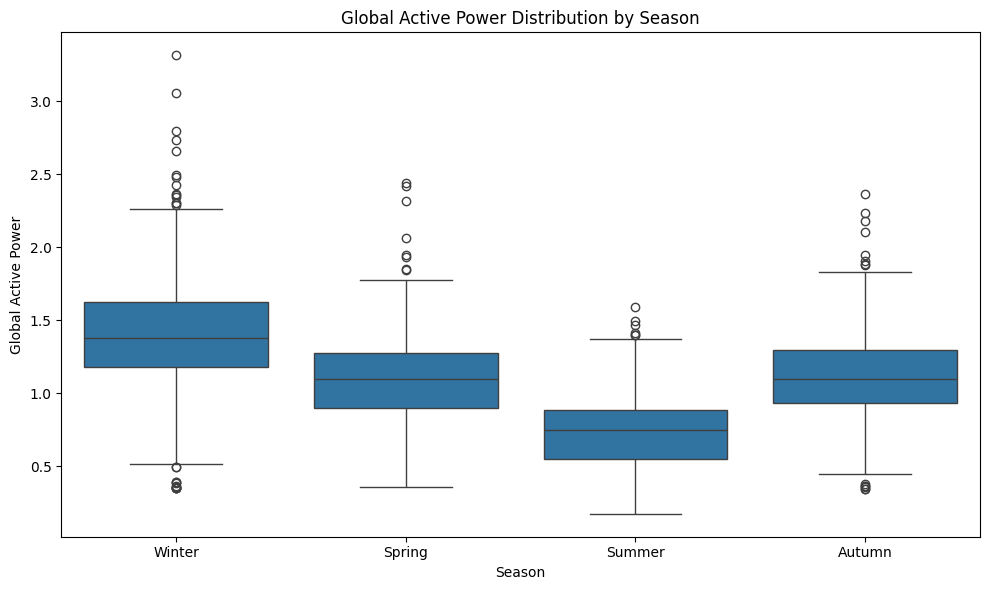

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_daily,
    x='season',
    y='Global_active_power',
    order=['Winter', 'Spring', 'Summer', 'Autumn']
)

plt.title('Global Active Power Distribution by Season')
plt.xlabel('Season')
plt.ylabel('Global Active Power')
plt.tight_layout()
plt.show()

### 1.2.2 Hourly

In [ ]:
!pip install astral
from astral import LocationInfo
from astral.sun import sun
import pandas as pd

city = LocationInfo("Paris", "France", "Europe/Paris", 48.8566, 2.3522)

dates = pd.date_range(df.index.min().date(), df.index.max().date())

data = []

for d in dates:
    s = sun(city.observer, date=d)
    data.append({
        "date": d,
        "sunrise": s["sunrise"],
        "sunset": s["sunset"]
    })

df_sun = pd.DataFrame(data).set_index("date")

df_sun["sunrise"] = df_sun["sunrise"].dt.tz_localize(None)
df_sun["sunset"] = df_sun["sunset"].dt.tz_localize(None)

In [ ]:
df = df.drop(columns=["sunrise", "sunset", "is_day"], errors="ignore")

df = df.join(
    df_sun[["sunrise", "sunset"]],
    on=df.index.normalize()
)

df["is_day"] = (
    (df.index >= df["sunrise"]) &
    (df.index <= df["sunset"])
).astype(int)

In [ ]:
df["is_day"].value_counts()

,count
is_day,
1,1053493
0,1004137


In [ ]:
df.head()

,key_0,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Global_active_power,sunrise,sunset,is_day
datetime,,,,,,,,,,,
2006-12-16 17:24:00,2006-12-16,0.42,234.84,18.40,0.00,1.00,17.00,4.22,2006-12-16 07:38:21.109905,2006-12-16 15:53:54.732076,0
2006-12-16 17:25:00,2006-12-16,0.44,233.63,23.00,0.00,1.00,16.00,5.36,2006-12-16 07:38:21.109905,2006-12-16 15:53:54.732076,0
2006-12-16 17:26:00,2006-12-16,0.50,233.29,23.00,0.00,2.00,17.00,5.37,2006-12-16 07:38:21.109905,2006-12-16 15:53:54.732076,0
2006-12-16 17:27:00,2006-12-16,0.50,233.74,23.00,0.00,1.00,17.00,5.39,2006-12-16 07:38:21.109905,2006-12-16 15:53:54.732076,0
2006-12-16 17:28:00,2006-12-16,0.53,235.68,15.80,0.00,1.00,17.00,3.67,2006-12-16 07:38:21.109905,2006-12-16 15:53:54.732076,0


In [ ]:
df_hourly = df.resample('H').agg({
    'Global_active_power': 'mean',
    'Global_reactive_power': 'mean',
    'Voltage': 'mean',
    'Global_intensity': 'mean',
    'Sub_metering_1': 'sum',
    'Sub_metering_2': 'sum',
    'Sub_metering_3': 'sum',
    'is_day': 'mean'
})

df_hourly['is_day'] = (df_hourly['is_day'] >= 0.5).astype(int)

df_hourly = df_hourly.dropna()

df_hourly.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,is_day
datetime,,,,,,,,
2006-12-16 17:00:00,4.22,0.23,234.64,18.10,0.00,19.00,607.00,0
2006-12-16 18:00:00,3.63,0.08,234.58,15.60,0.00,403.00,1012.00,0
2006-12-16 19:00:00,3.40,0.09,233.23,14.50,0.00,86.00,1001.00,0
2006-12-16 20:00:00,3.27,0.08,234.07,13.92,0.00,0.00,1007.00,0
2006-12-16 21:00:00,3.06,0.08,237.16,13.05,0.00,25.00,1033.00,0


In [ ]:
df_hourly.is_day.value_counts()

,count
is_day,
1,17554
0,16744


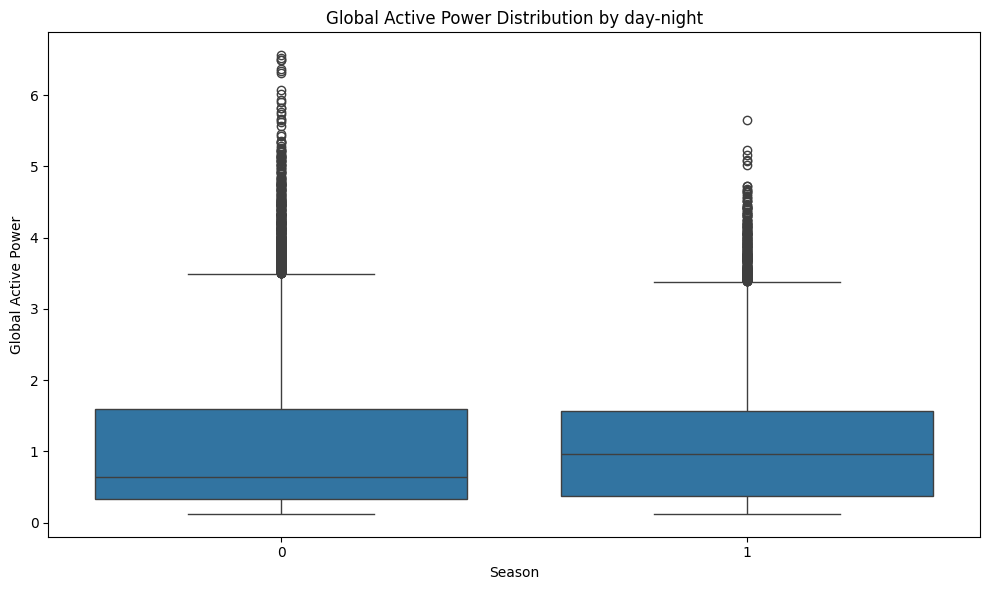

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_hourly,
    x='is_day',
    y='Global_active_power'
)

plt.title('Global Active Power Distribution by day-night')
plt.xlabel('Season')
plt.ylabel('Global Active Power')
plt.tight_layout()
plt.show()

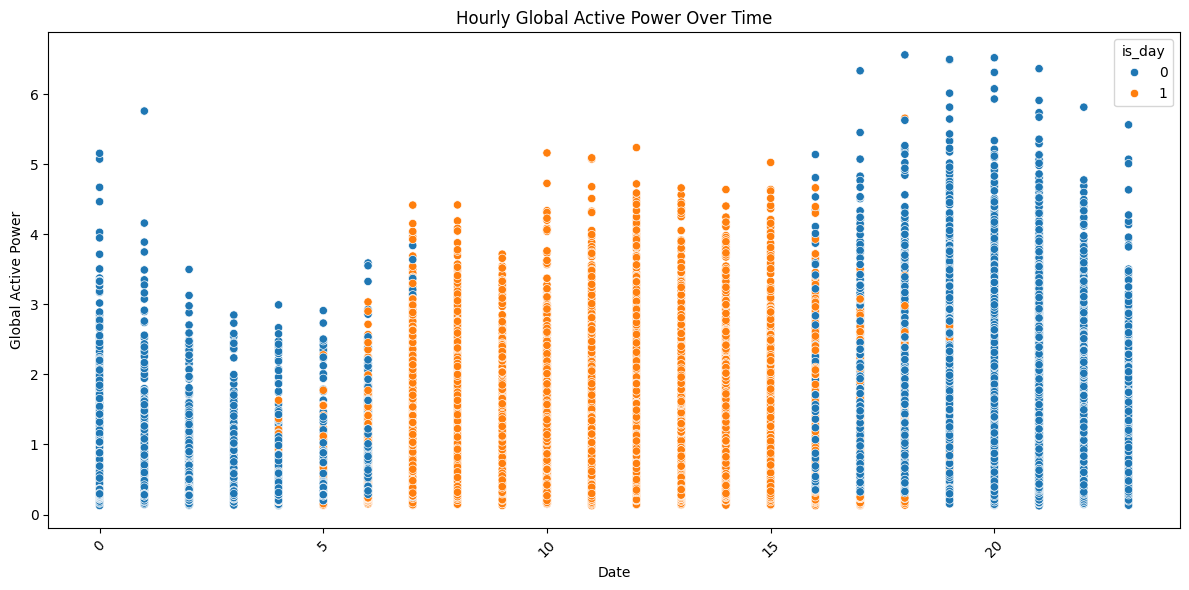

In [ ]:
plt.figure(figsize=(12,6))

df_hourly_pre_2008 = df_hourly[df_hourly.index.year < 2008]

sns.scatterplot(
    data=df_hourly_pre_2008,
    x=df_hourly_pre_2008.index.hour,
    y='Global_active_power',
    hue='is_day'
)

plt.title('Hourly Global Active Power Over Time')
plt.xlabel('Date')
plt.ylabel('Global Active Power')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df.head()

,key_0,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Global_active_power,sunrise,sunset,is_day
datetime,,,,,,,,,,,
2006-12-16 17:24:00,2006-12-16,0.42,234.84,18.40,0.00,1.00,17.00,4.22,2006-12-16 07:38:21.109905,2006-12-16 15:53:54.732076,0
2006-12-16 17:25:00,2006-12-16,0.44,233.63,23.00,0.00,1.00,16.00,5.36,2006-12-16 07:38:21.109905,2006-12-16 15:53:54.732076,0
2006-12-16 17:26:00,2006-12-16,0.50,233.29,23.00,0.00,2.00,17.00,5.37,2006-12-16 07:38:21.109905,2006-12-16 15:53:54.732076,0
2006-12-16 17:27:00,2006-12-16,0.50,233.74,23.00,0.00,1.00,17.00,5.39,2006-12-16 07:38:21.109905,2006-12-16 15:53:54.732076,0
2006-12-16 17:28:00,2006-12-16,0.53,235.68,15.80,0.00,1.00,17.00,3.67,2006-12-16 07:38:21.109905,2006-12-16 15:53:54.732076,0


In [ ]:
def get_dynamic_period(row):
    if pd.isna(row['sunrise']) or pd.isna(row['sunset']):
        return np.nan

    t = row.name  # datetime index

    sunrise = row['sunrise']
    sunset = row['sunset']

    morning_end = sunrise + pd.Timedelta(hours=4)
    evening_start = sunset - pd.Timedelta(hours=2)

    if sunrise <= t < morning_end:
        return 'Morning'
    elif morning_end <= t < evening_start:
        return 'Afternoon'
    elif evening_start <= t <= sunset:
        return 'Evening'
    else:
        return 'Night'


df['day_period'] = df.apply(get_dynamic_period, axis=1)

In [ ]:
df.head()

,key_0,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Global_active_power,sunrise,sunset,is_day,day_period
datetime,,,,,,,,,,,,
2006-12-16 17:24:00,2006-12-16,0.42,234.84,18.40,0.00,1.00,17.00,4.22,2006-12-16 07:38:21.109905,2006-12-16 15:53:54.732076,0,Night
2006-12-16 17:25:00,2006-12-16,0.44,233.63,23.00,0.00,1.00,16.00,5.36,2006-12-16 07:38:21.109905,2006-12-16 15:53:54.732076,0,Night
2006-12-16 17:26:00,2006-12-16,0.50,233.29,23.00,0.00,2.00,17.00,5.37,2006-12-16 07:38:21.109905,2006-12-16 15:53:54.732076,0,Night
2006-12-16 17:27:00,2006-12-16,0.50,233.74,23.00,0.00,1.00,17.00,5.39,2006-12-16 07:38:21.109905,2006-12-16 15:53:54.732076,0,Night
2006-12-16 17:28:00,2006-12-16,0.53,235.68,15.80,0.00,1.00,17.00,3.67,2006-12-16 07:38:21.109905,2006-12-16 15:53:54.732076,0,Night


In [ ]:
df['day_period'].value_counts()

,count
day_period,
Night,1004137
Afternoon,539380
Morning,342720
Evening,171393


In [ ]:
numeric_cols = df.select_dtypes(include='number').columns

df_hourly = df.resample('H').agg({
    'Global_active_power': 'mean',
    'Global_reactive_power': 'mean',
    'Voltage': 'mean',
    'Global_intensity': 'mean',
    'Sub_metering_1': 'sum',
    'Sub_metering_2': 'sum',
    'Sub_metering_3': 'sum',
    'is_day': 'mean'
})

df_hourly['is_day'] = (df_hourly['is_day'] >= 0.5).astype(int)

df_hourly = df_hourly.drop(columns=['sunrise', 'sunset'], errors='ignore')

df_hourly = df_hourly.join(
    df[['sunrise', 'sunset']],
    how='left'
)

def get_dynamic_period(row):
    if pd.isna(row['sunrise']) or pd.isna(row['sunset']):
        return np.nan

    t = row.name
    sunrise = row['sunrise']
    sunset = row['sunset']

    morning_end = sunrise + pd.Timedelta(hours=4)
    evening_start = sunset - pd.Timedelta(hours=2)

    if sunrise <= t < morning_end:
        return 'Morning'
    elif morning_end <= t < evening_start:
        return 'Afternoon'
    elif evening_start <= t <= sunset:
        return 'Evening'
    else:
        return 'Night'

df_hourly['day_period'] = df_hourly.apply(get_dynamic_period, axis=1)

df_hourly = df_hourly.drop(columns=['sunrise', 'sunset'], errors='ignore')
df_hourly = df_hourly.dropna()

df_hourly.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,is_day,day_period
datetime,,,,,,,,,
2006-12-16 18:00:00,3.63,0.08,234.58,15.60,0.00,403.00,1012.00,0,Night
2006-12-16 19:00:00,3.40,0.09,233.23,14.50,0.00,86.00,1001.00,0,Night
2006-12-16 20:00:00,3.27,0.08,234.07,13.92,0.00,0.00,1007.00,0,Night
2006-12-16 21:00:00,3.06,0.08,237.16,13.05,0.00,25.00,1033.00,0,Night
2006-12-16 22:00:00,2.20,0.06,238.76,9.52,0.00,8.00,266.00,0,Night


In [ ]:
df_hourly['day_period'].value_counts()

,count
day_period,
Night,16767
Afternoon,8958
Morning,5712
Evening,2856


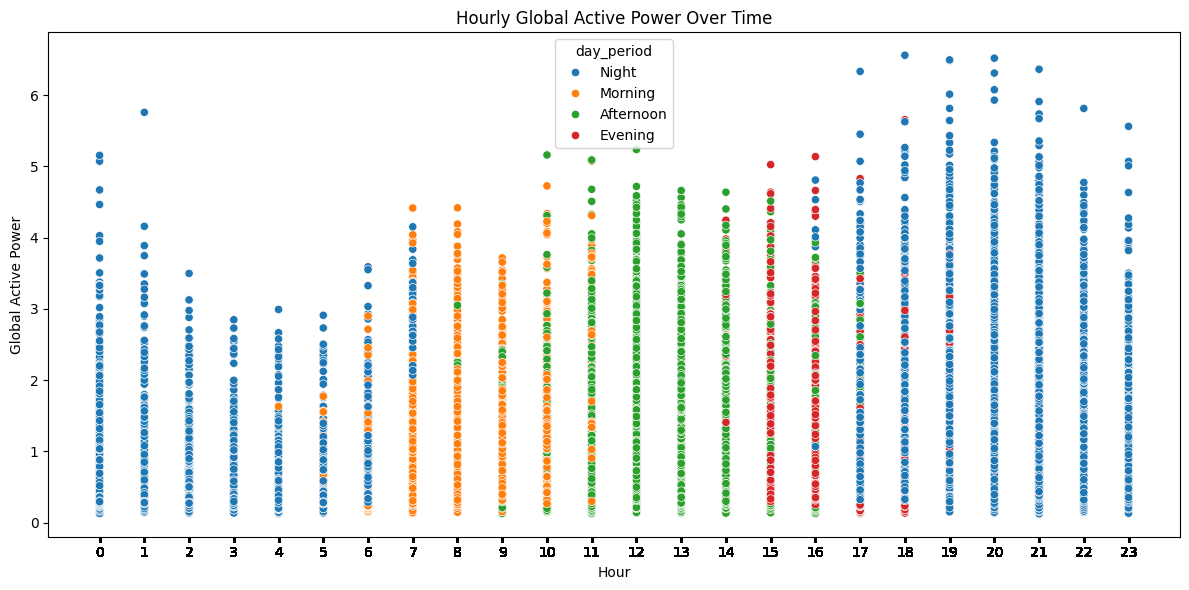

In [ ]:
plt.figure(figsize=(12,6))


sns.scatterplot(
    data=df_hourly,
    x=df_hourly.index.hour,
    y='Global_active_power',
    hue='day_period'
)

plt.title('Hourly Global Active Power Over Time')
plt.xlabel('Hour')
plt.ylabel('Global Active Power')
plt.xticks(df_hourly.index.hour)
plt.tight_layout()

In [ ]:
df_hourly_mean = df_hourly.groupby([df_hourly.index.hour, 'day_period'])['Global_active_power'].mean().reset_index()
df_hourly_mean = df_hourly_mean.rename(columns={df_hourly_mean.columns[0]: 'hour'})

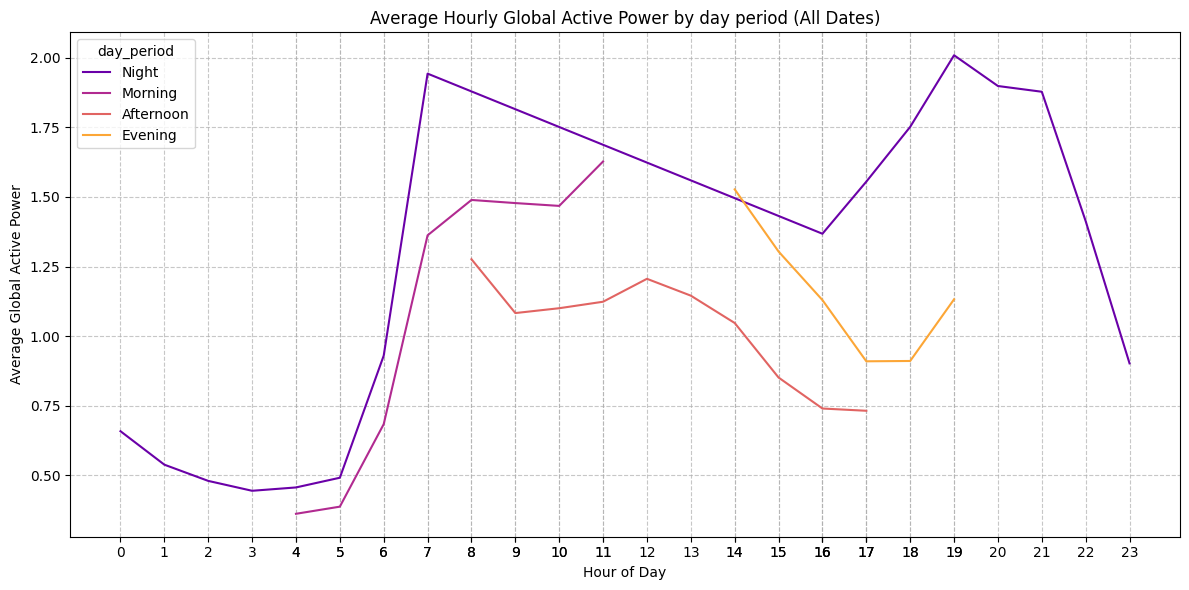

In [ ]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=df_hourly_mean,
    x='hour',
    y='Global_active_power',
    hue='day_period',
    palette='plasma'
)

plt.title('Average Hourly Global Active Power by day period (All Dates)')
plt.xlabel('Hour of Day')
plt.ylabel('Average Global Active Power')
plt.xticks(df_hourly_mean['hour'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

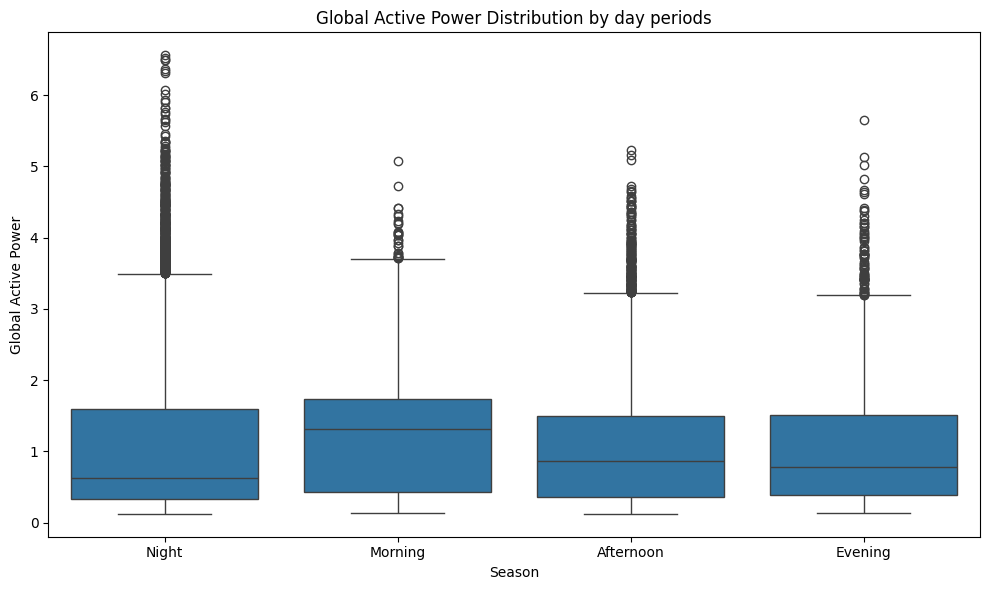

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_hourly,
    x='day_period',
    y='Global_active_power'
)

plt.title('Global Active Power Distribution by day periods')
plt.xlabel('Season')
plt.ylabel('Global Active Power')
plt.tight_layout()
plt.show()

([<matplotlib.axis.XTick at 0x7fc41b971a60>,
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(10, 0, '10'),
  Text(11, 0, '11'),
  Text(11, 0, '11'),
  Text(12, 0, '12'),
  Text(13, 0, '13'),
  Text(14, 0, '14'),
  Text(14, 0, '14'),
  Text(15, 0, '15'),
  Text(15, 0, '15'),
  Text(16, 0, '16'),
  Text(16, 0, '16'),
  Text(16, 0, '16'),
  Text(17, 0, '17'),
  Text(17, 0, '17'),
  Text(17, 0, '17'),
  Text(18, 0, '18'),
  Text(18, 0, '18'),
  Text(19, 0, '19'),
  Text(19, 0, '19'),
  Text(20, 0, '20'),
  Text(21, 0, '21'),
  Text(22, 0, '22'),
  Text(23, 0, '23')])

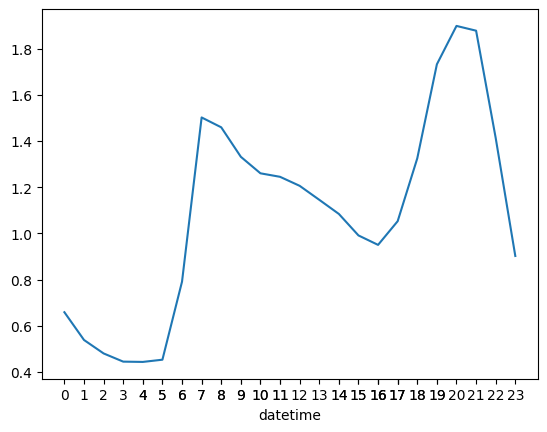

In [ ]:
df_hourly.groupby(df_hourly.index.hour)['Global_active_power'].mean().plot()
plt.xticks(df_hourly_mean['hour'])

In [ ]:
df_hourly.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,is_day,day_period
datetime,,,,,,,,,
2006-12-16 18:00:00,3.63,0.08,234.58,15.60,0.00,403.00,1012.00,0,Night
2006-12-16 19:00:00,3.40,0.09,233.23,14.50,0.00,86.00,1001.00,0,Night
2006-12-16 20:00:00,3.27,0.08,234.07,13.92,0.00,0.00,1007.00,0,Night
2006-12-16 21:00:00,3.06,0.08,237.16,13.05,0.00,25.00,1033.00,0,Night
2006-12-16 22:00:00,2.20,0.06,238.76,9.52,0.00,8.00,266.00,0,Night


In [ ]:
df.head()

,key_0,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Global_active_power,sunrise,sunset,is_day,day_period
datetime,,,,,,,,,,,,
2006-12-16 17:24:00,2006-12-16,0.42,234.84,18.40,0.00,1.00,17.00,4.22,2006-12-16 07:38:21.109905,2006-12-16 15:53:54.732076,0,Night
2006-12-16 17:25:00,2006-12-16,0.44,233.63,23.00,0.00,1.00,16.00,5.36,2006-12-16 07:38:21.109905,2006-12-16 15:53:54.732076,0,Night
2006-12-16 17:26:00,2006-12-16,0.50,233.29,23.00,0.00,2.00,17.00,5.37,2006-12-16 07:38:21.109905,2006-12-16 15:53:54.732076,0,Night
2006-12-16 17:27:00,2006-12-16,0.50,233.74,23.00,0.00,1.00,17.00,5.39,2006-12-16 07:38:21.109905,2006-12-16 15:53:54.732076,0,Night
2006-12-16 17:28:00,2006-12-16,0.53,235.68,15.80,0.00,1.00,17.00,3.67,2006-12-16 07:38:21.109905,2006-12-16 15:53:54.732076,0,Night


In [ ]:
df_hourly = df_hourly.drop(columns=['sunrise', 'sunset'], errors='ignore')
df_hourly = df_hourly.join(
    df[['sunrise', 'sunset']],
    how='left'
)
def get_dynamic_detailed_period(row):
    t = row.name
    sunrise = row['sunrise']
    sunset = row['sunset']

    if pd.isna(sunrise) or pd.isna(sunset):
        return np.nan

    # boundaries
    pre_morning_start = sunrise - pd.Timedelta(hours=2)
    morning_ramp_end = sunrise + pd.Timedelta(hours=2)
    late_morning_end = sunrise + pd.Timedelta(hours=4)

    evening_ramp_start = sunset - pd.Timedelta(hours=3)
    evening_peak_start = sunset - pd.Timedelta(hours=1)
    late_night_end = sunset + pd.Timedelta(hours=2)

    if t < pre_morning_start:
        return 'Deep_Night'
    elif pre_morning_start <= t < sunrise:
        return 'Pre_Morning'
    elif sunrise <= t < morning_ramp_end:
        return 'Morning_Ramp'
    elif morning_ramp_end <= t < late_morning_end:
        return 'Late_Morning'
    elif late_morning_end <= t < evening_ramp_start:
        return 'Afternoon'
    elif evening_ramp_start <= t < evening_peak_start:
        return 'Late_Afternoon'
    elif evening_peak_start <= t <= sunset:
        return 'Evening_Peak'
    elif sunset < t <= late_night_end:
        return 'Late_Night'
    else:
        return 'Deep_Night'

df_hourly['day_period_detailed'] = df_hourly.apply(get_dynamic_detailed_period, axis=1)
df_hourly.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,is_day,day_period,sunrise,sunset,day_period_detailed
datetime,,,,,,,,,,,,
2006-12-16 18:00:00,3.63,0.08,234.58,15.60,0.00,403.00,1012.00,0,Night,2006-12-16 07:38:21.109905,2006-12-16 15:53:54.732076,Deep_Night
2006-12-16 19:00:00,3.40,0.09,233.23,14.50,0.00,86.00,1001.00,0,Night,2006-12-16 07:38:21.109905,2006-12-16 15:53:54.732076,Deep_Night
2006-12-16 20:00:00,3.27,0.08,234.07,13.92,0.00,0.00,1007.00,0,Night,2006-12-16 07:38:21.109905,2006-12-16 15:53:54.732076,Deep_Night
2006-12-16 21:00:00,3.06,0.08,237.16,13.05,0.00,25.00,1033.00,0,Night,2006-12-16 07:38:21.109905,2006-12-16 15:53:54.732076,Deep_Night
2006-12-16 22:00:00,2.20,0.06,238.76,9.52,0.00,8.00,266.00,0,Night,2006-12-16 07:38:21.109905,2006-12-16 15:53:54.732076,Deep_Night


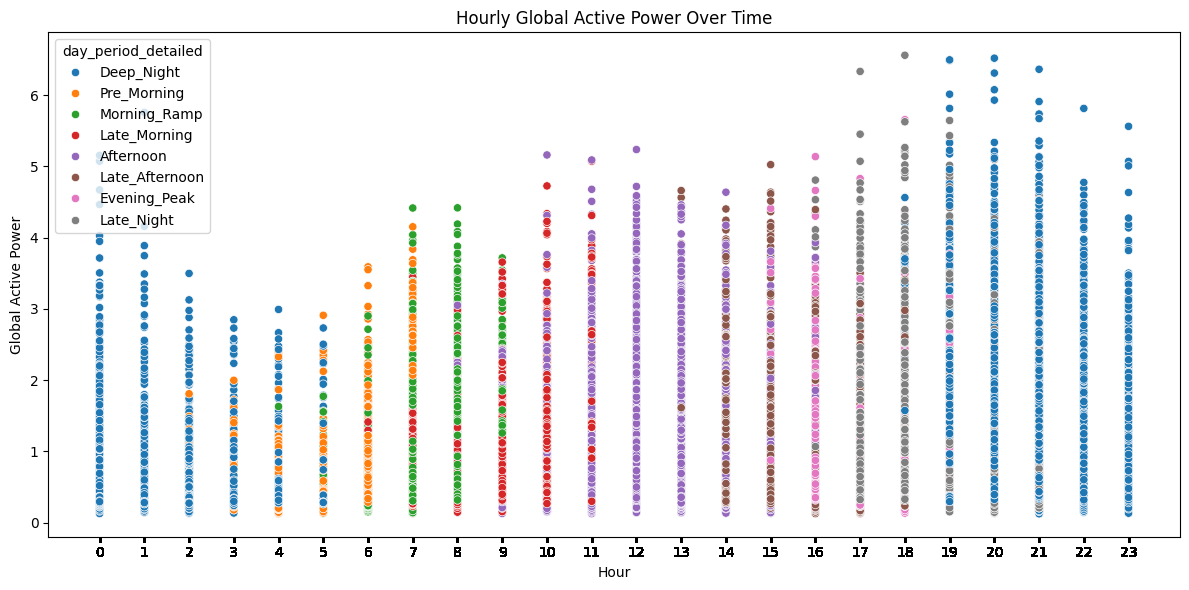

In [ ]:
plt.figure(figsize=(12,6))


sns.scatterplot(
    data=df_hourly,
    x=df_hourly.index.hour,
    y='Global_active_power',
    hue='day_period_detailed'
)

plt.title('Hourly Global Active Power Over Time')
plt.xlabel('Hour')
plt.ylabel('Global Active Power')
plt.xticks(df_hourly.index.hour)
plt.tight_layout()

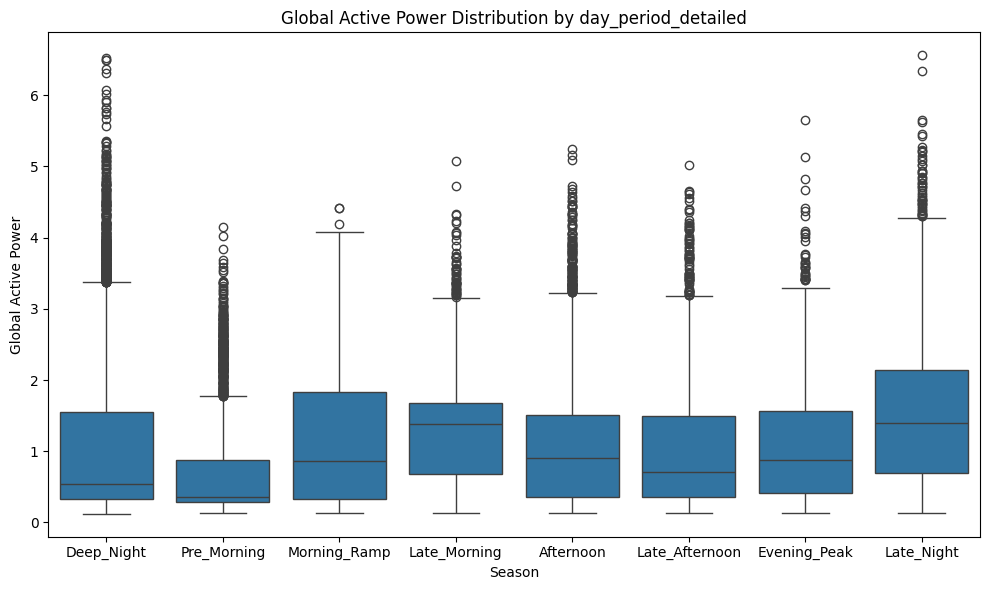

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_hourly,
    x='day_period_detailed',
    y='Global_active_power'
)

plt.title('Global Active Power Distribution by day_period_detailed')
plt.xlabel('Season')
plt.ylabel('Global Active Power')
plt.tight_layout()
plt.show()

In [ ]:
df_hourly_mean3 = (
    df_hourly
    .groupby([df_hourly.index.hour, 'day_period_detailed'])['Global_active_power']
    .mean()
    .reset_index()
)

df_hourly_mean3 = df_hourly_mean3.rename(columns={'datetime': 'hour'})
df_hourly_mean3.head()

,hour,day_period_detailed,Global_active_power
0,0,Deep_Night,0.66
1,1,Deep_Night,0.54
2,2,Deep_Night,0.50
3,2,Pre_Morning,0.38
4,3,Deep_Night,0.48


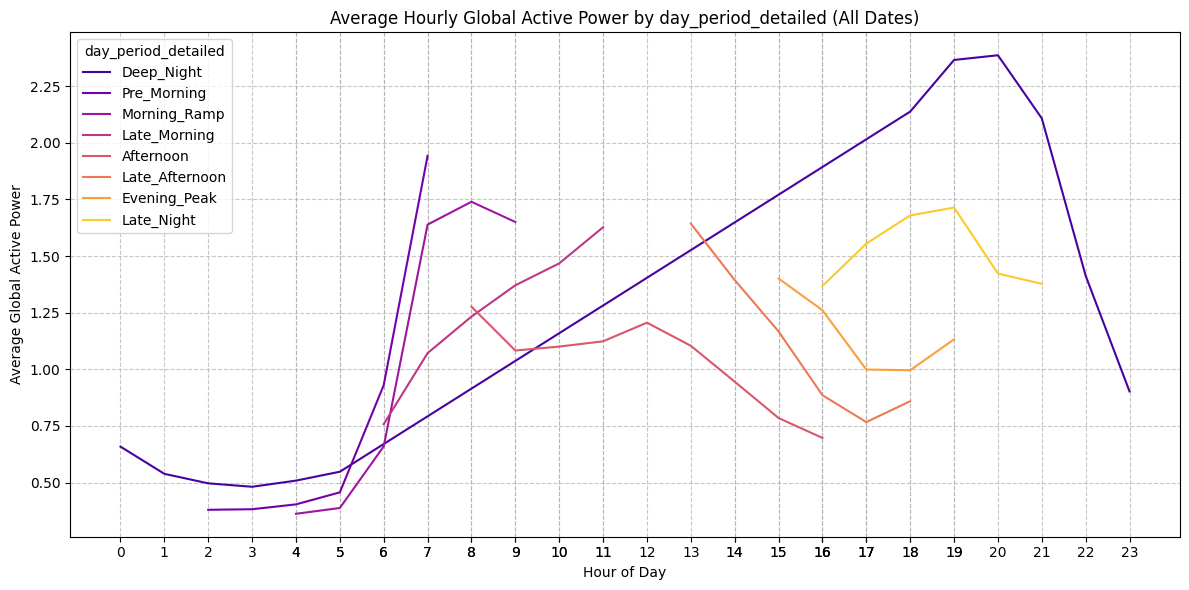

In [ ]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=df_hourly_mean3,
    x='hour',
    y='Global_active_power',
    hue='day_period_detailed',
    palette='plasma' # Changed to 'plasma' palette
)

plt.title('Average Hourly Global Active Power by day_period_detailed (All Dates)')
plt.xlabel('Hour of Day')
plt.ylabel('Average Global Active Power')
plt.xticks(df_hourly_mean['hour'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**<font size="5">
<font color="#4285F4">
from df_hourly eda we conclude that there is much noise in the day periods and there is no specific pattern can be observed
</font>
</font>**

# ***2.FEATURE ENGINEERING***

In [ ]:
df_daily.head()

,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Global_active_power,month,day_of_week,is_weekend,season
datetime,,,,,,,,,,,
2006-12-16,0.09,236.24,13.08,0.00,1.38,12.44,3.05,12,5,1,Winter
2006-12-17,0.16,240.09,10.00,1.41,2.91,9.26,2.35,12,6,1,Winter
2006-12-18,0.11,241.23,6.42,0.74,1.82,9.73,1.53,12,0,0,Winter
2006-12-19,0.10,242.00,4.93,0.58,5.28,4.30,1.16,12,1,0,Winter
2006-12-20,0.11,242.31,6.47,0.00,1.84,9.77,1.55,12,2,0,Winter


In [ ]:
df = df.resample('D').agg({
    'Global_active_power': 'mean',
    'Global_reactive_power': 'mean',
    'Voltage': 'mean',
    'Global_intensity': 'mean',
    'Sub_metering_1': 'sum',
    'Sub_metering_2': 'sum',
    'Sub_metering_3': 'sum',
    'is_day': 'mean'
})

df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,is_day
datetime,,,,,,,,
2006-12-16,3.05,0.09,236.24,13.08,0.00,546.00,4926.00,0.00
2006-12-17,2.35,0.16,240.09,10.00,2033.00,4187.00,13341.00,0.34
2006-12-18,1.53,0.11,241.23,6.42,1063.00,2621.00,14018.00,0.34
2006-12-19,1.16,0.10,242.00,4.93,839.00,7602.00,6197.00,0.34
2006-12-20,1.55,0.11,242.31,6.47,0.00,2648.00,14063.00,0.34


In [ ]:
df.drop("is_day",axis=1,inplace=True)
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16,3.05,0.09,236.24,13.08,0.00,546.00,4926.00
2006-12-17,2.35,0.16,240.09,10.00,2033.00,4187.00,13341.00
2006-12-18,1.53,0.11,241.23,6.42,1063.00,2621.00,14018.00
2006-12-19,1.16,0.10,242.00,4.93,839.00,7602.00,6197.00
2006-12-20,1.55,0.11,242.31,6.47,0.00,2648.00,14063.00


## 2.1 adding day of week column

In [ ]:
df['day_of_week'] = df.index.dayofweek


df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,day_of_week
datetime,,,,,,,,
2006-12-16,3.05,0.09,236.24,13.08,0.00,546.00,4926.00,5
2006-12-17,2.35,0.16,240.09,10.00,2033.00,4187.00,13341.00,6
2006-12-18,1.53,0.11,241.23,6.42,1063.00,2621.00,14018.00,0
2006-12-19,1.16,0.10,242.00,4.93,839.00,7602.00,6197.00,1
2006-12-20,1.55,0.11,242.31,6.47,0.00,2648.00,14063.00,2


## **2.2 adding weekend day flag**

In [ ]:
df['is_weekend'] = (
    df['day_of_week'].isin([5,6])
).astype(int)
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,day_of_week,is_weekend
datetime,,,,,,,,,
2006-12-16,3.05,0.09,236.24,13.08,0.00,546.00,4926.00,5,1
2006-12-17,2.35,0.16,240.09,10.00,2033.00,4187.00,13341.00,6,1
2006-12-18,1.53,0.11,241.23,6.42,1063.00,2621.00,14018.00,0,0
2006-12-19,1.16,0.10,242.00,4.93,839.00,7602.00,6197.00,1,0
2006-12-20,1.55,0.11,242.31,6.47,0.00,2648.00,14063.00,2,0


## 2.3 adding month column

In [ ]:
df['month'] = df.index.month
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,day_of_week,is_weekend,month
datetime,,,,,,,,,,
2006-12-16,3.05,0.09,236.24,13.08,0.00,546.00,4926.00,5,1,12
2006-12-17,2.35,0.16,240.09,10.00,2033.00,4187.00,13341.00,6,1,12
2006-12-18,1.53,0.11,241.23,6.42,1063.00,2621.00,14018.00,0,0,12
2006-12-19,1.16,0.10,242.00,4.93,839.00,7602.00,6197.00,1,0,12
2006-12-20,1.55,0.11,242.31,6.47,0.00,2648.00,14063.00,2,0,12


## **2.4 adding season column**

In [ ]:
def get_season(month):
    if month in [12,1,2]:
        return 'Winter'
    elif month in [3,4,5]:
        return 'Spring'
    elif month in [6,7,8]:
        return 'Summer'
    else:
        return 'Autumn'

df['season'] = df['month'].apply(get_season)
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,day_of_week,is_weekend,month,season
datetime,,,,,,,,,,,
2006-12-16,3.05,0.09,236.24,13.08,0.00,546.00,4926.00,5,1,12,Winter
2006-12-17,2.35,0.16,240.09,10.00,2033.00,4187.00,13341.00,6,1,12,Winter
2006-12-18,1.53,0.11,241.23,6.42,1063.00,2621.00,14018.00,0,0,12,Winter
2006-12-19,1.16,0.10,242.00,4.93,839.00,7602.00,6197.00,1,0,12,Winter
2006-12-20,1.55,0.11,242.31,6.47,0.00,2648.00,14063.00,2,0,12,Winter


## **2.5 adding lags features**

In [ ]:
df['lag_1'] = df['Global_active_power'].shift(1)

df['lag_7'] = df['Global_active_power'].shift(7)
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,day_of_week,is_weekend,month,season,lag_1,lag_7
datetime,,,,,,,,,,,,,
2006-12-16,3.05,0.09,236.24,13.08,0.00,546.00,4926.00,5,1,12,Winter,NaN,NaN
2006-12-17,2.35,0.16,240.09,10.00,2033.00,4187.00,13341.00,6,1,12,Winter,3.05,NaN
2006-12-18,1.53,0.11,241.23,6.42,1063.00,2621.00,14018.00,0,0,12,Winter,2.35,NaN
2006-12-19,1.16,0.10,242.00,4.93,839.00,7602.00,6197.00,1,0,12,Winter,1.53,NaN
2006-12-20,1.55,0.11,242.31,6.47,0.00,2648.00,14063.00,2,0,12,Winter,1.16,NaN


In [ ]:
df.isnull().sum()

,0
Global_active_power,7
Global_reactive_power,7
Voltage,7
Global_intensity,7
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,0
day_of_week,0
is_weekend,0
month,0


In [ ]:
df[df['Global_active_power'].isnull()]

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,day_of_week,is_weekend,month,season,lag_1,lag_7
datetime,,,,,,,,,,,,,
2010-01-13,NaN,NaN,NaN,NaN,0.00,0.00,0.00,2,0,1,Winter,1.44,1.23
2010-08-18,NaN,NaN,NaN,NaN,0.00,0.00,0.00,2,0,8,Summer,0.78,0.38
2010-08-19,NaN,NaN,NaN,NaN,0.00,0.00,0.00,3,0,8,Summer,NaN,0.37
2010-08-20,NaN,NaN,NaN,NaN,0.00,0.00,0.00,4,0,8,Summer,NaN,0.37
2010-08-21,NaN,NaN,NaN,NaN,0.00,0.00,0.00,5,1,8,Summer,NaN,0.38
2010-09-26,NaN,NaN,NaN,NaN,0.00,0.00,0.00,6,1,9,Autumn,0.45,0.64
2010-09-27,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0,0,9,Autumn,NaN,1.17


In [ ]:
df = df.iloc[7:]
df.isnull().sum()

,0
Global_active_power,7
Global_reactive_power,7
Voltage,7
Global_intensity,7
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,0
day_of_week,0
is_weekend,0
month,0


In [ ]:
df['rolling_mean_7'] = df['Global_active_power'].shift(1).rolling(7).mean()
df['rolling_std_7'] = df['Global_active_power'].shift(1).rolling(7).std()
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,day_of_week,is_weekend,month,season,lag_1,lag_7,rolling_mean_7,rolling_std_7
datetime,,,,,,,,,,,,,,,
2006-12-23,3.31,0.15,240.14,14.03,2669.00,425.00,14726.00,5,1,12,Winter,1.63,3.05,NaN,NaN
2006-12-24,1.77,0.10,241.69,7.64,1703.00,5082.00,6891.00,6,1,12,Winter,3.31,2.35,NaN,NaN
2006-12-25,1.90,0.17,243.40,7.95,6620.00,1962.00,5795.00,0,0,12,Winter,1.77,1.53,NaN,NaN
2006-12-26,2.73,0.11,241.63,11.35,1086.00,2533.00,14979.00,1,0,12,Winter,1.90,1.16,NaN,NaN
2006-12-27,1.06,0.12,243.77,4.52,0.00,314.00,6976.00,2,0,12,Winter,2.73,1.55,NaN,NaN


In [ ]:
df.isnull().sum()

,0
Global_active_power,7
Global_reactive_power,7
Voltage,7
Global_intensity,7
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,0
day_of_week,0
is_weekend,0
month,0


In [ ]:
df[df['rolling_mean_7'].isnull()]

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,day_of_week,is_weekend,month,season,lag_1,lag_7,rolling_mean_7,rolling_std_7
datetime,,,,,,,,,,,,,,,
2006-12-23,3.31,0.15,240.14,14.03,2669.00,425.00,14726.00,5,1,12,Winter,1.63,3.05,NaN,NaN
2006-12-24,1.77,0.10,241.69,7.64,1703.00,5082.00,6891.00,6,1,12,Winter,3.31,2.35,NaN,NaN
2006-12-25,1.90,0.17,243.40,7.95,6620.00,1962.00,5795.00,0,0,12,Winter,1.77,1.53,NaN,NaN
2006-12-26,2.73,0.11,241.63,11.35,1086.00,2533.00,14979.00,1,0,12,Winter,1.90,1.16,NaN,NaN
2006-12-27,1.06,0.12,243.77,4.52,0.00,314.00,6976.00,2,0,12,Winter,2.73,1.55,NaN,NaN
2006-12-28,1.44,0.15,243.27,6.09,2207.00,4419.00,9176.00,3,0,12,Winter,1.06,1.19,NaN,NaN
2006-12-29,2.20,0.14,240.87,9.27,1252.00,5162.00,11329.00,4,0,12,Winter,1.44,1.63,NaN,NaN
2010-01-14,2.08,0.24,243.58,8.68,1890.00,84.00,1893.00,3,0,1,Winter,NaN,1.23,NaN,NaN
2010-01-15,1.53,0.15,243.73,6.33,1957.00,2952.00,13546.00,4,0,1,Winter,2.08,1.25,NaN,NaN


In [ ]:
df=df.dropna()
df.isnull().sum()

,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,0
day_of_week,0
is_weekend,0
month,0


# ***3.EDA AFTER FEATURE ENGINEERING***

In [ ]:
df.columns

Index(['Global_active_power', 'Global_reactive_power', 'Voltage',
       'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3', 'day_of_week', 'is_weekend', 'month', 'season',
       'lag_1', 'lag_7', 'rolling_mean_7', 'rolling_std_7'],
      dtype='object')

In [ ]:
df=df[['Global_reactive_power', 'Voltage',
       'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3', 'day_of_week', 'is_weekend', 'month', 'season',
       'lag_1', 'lag_7', 'rolling_mean_7', 'rolling_std_7','Global_active_power']]

In [ ]:
df.head()

,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,day_of_week,is_weekend,month,season,lag_1,lag_7,rolling_mean_7,rolling_std_7,Global_active_power
datetime,,,,,,,,,,,,,,,
2006-12-30,0.22,240.54,8.32,3147.00,7938.00,12515.00,5,1,12,Winter,2.20,3.31,2.06,0.77,1.95
2006-12-31,0.10,239.90,10.20,0.00,347.00,6502.00,6,1,12,Winter,1.95,1.77,1.87,0.53,2.43
2007-01-01,0.10,240.13,7.92,0.00,352.00,5880.00,0,0,1,Winter,2.43,1.90,1.96,0.57,1.91
2007-01-02,0.13,241.94,3.71,0.00,348.00,6562.00,1,0,1,Winter,1.91,2.73,1.96,0.57,0.88
2007-01-03,0.14,243.56,3.01,0.00,344.00,4765.00,2,0,1,Winter,0.88,1.06,1.70,0.58,0.70


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Global_reactive_power,1400.00,0.12,0.03,0.06,0.10,0.12,0.14,0.29
Voltage,1400.00,240.82,2.04,231.09,240.06,240.95,241.84,247.44
Global_intensity,1400.00,4.59,1.69,0.81,3.50,4.53,5.52,11.82
Sub_metering_1,1400.00,1613.31,1596.62,0.00,654.25,1113.50,2216.75,11224.00
Sub_metering_2,1400.00,1858.69,2090.56,0.00,430.75,684.00,2741.12,12109.00
Sub_metering_3,1400.00,9240.05,3682.73,896.00,6670.75,9284.50,11682.50,23743.00
day_of_week,1400.00,3.00,2.00,0.00,1.00,3.00,5.00,6.00
is_weekend,1400.00,0.29,0.45,0.00,0.00,0.00,1.00,1.00
month,1400.00,6.40,3.39,1.00,3.00,6.00,9.00,12.00
lag_1,1400.00,1.08,0.41,0.17,0.81,1.07,1.31,2.80


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1400 entries, 2006-12-30 to 2010-11-26
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Global_reactive_power  1400 non-null   float64
 1   Voltage                1400 non-null   float64
 2   Global_intensity       1400 non-null   float64
 3   Sub_metering_1         1400 non-null   float64
 4   Sub_metering_2         1400 non-null   float64
 5   Sub_metering_3         1400 non-null   float64
 6   day_of_week            1400 non-null   int32  
 7   is_weekend             1400 non-null   int64  
 8   month                  1400 non-null   int32  
 9   season                 1400 non-null   object 
 10  lag_1                  1400 non-null   float64
 11  lag_7                  1400 non-null   float64
 12  rolling_mean_7         1400 non-null   float64
 13  rolling_std_7          1400 non-null   float64
 14  Global_active_power    1400 non-null  

## **3.1 spletting columns to continuous numerical , discrete numerical and categorical data**

In [ ]:
for i in df.columns:
  print(f'column {i} has {df[i].nunique()} unique values')
  print('****************************************************')

column Global_reactive_power has 1384 unique values
****************************************************
column Voltage has 1398 unique values
****************************************************
column Global_intensity has 1368 unique values
****************************************************
column Sub_metering_1 has 858 unique values
****************************************************
column Sub_metering_2 has 1012 unique values
****************************************************
column Sub_metering_3 has 1318 unique values
****************************************************
column day_of_week has 7 unique values
****************************************************
column is_weekend has 2 unique values
****************************************************
column month has 12 unique values
****************************************************
column season has 4 unique values
****************************************************
column lag_1 has 1398 unique values
******************

In [ ]:
disc_numerical_feat=df[['month','is_weekend','day_of_week']]
categorical_feat=df[['season']]
y=df[['Global_active_power']]
cont_numerical_feat=df[['Global_reactive_power','Voltage','Global_intensity','Sub_metering_1','Sub_metering_2','Sub_metering_3','lag_1','lag_7','rolling_mean_7','rolling_std_7']]


## **3.2 visualization for numerical features**

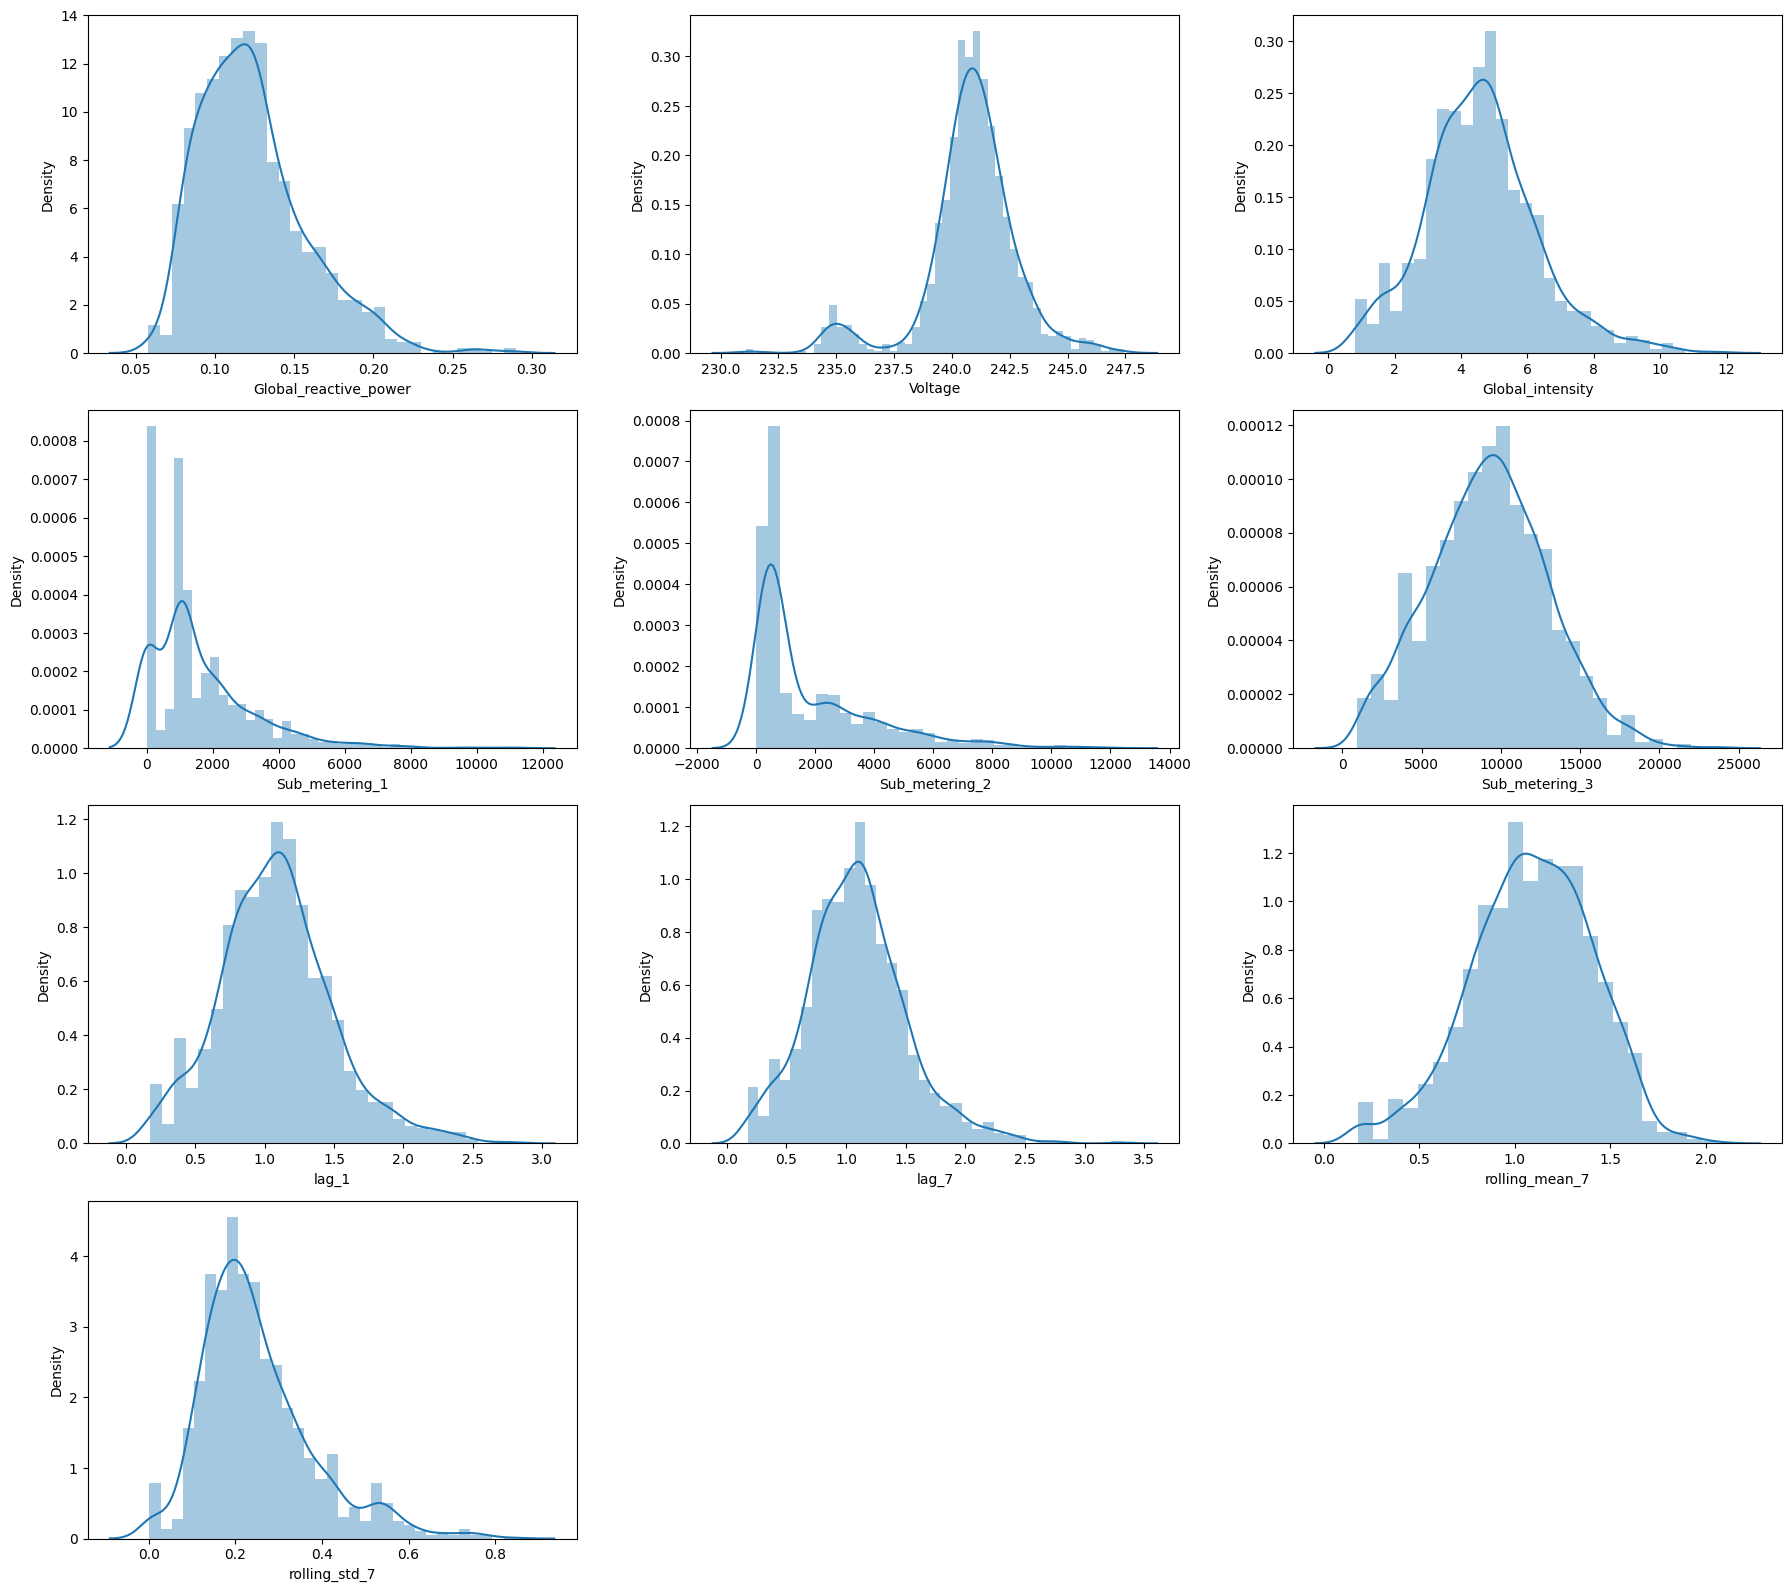

In [ ]:
fig = plt.figure(figsize=(18,16))
for index,col in enumerate(cont_numerical_feat):
    plt.subplot(4,3,index+1)
    sns.distplot(cont_numerical_feat.loc[:,col].dropna())
fig.tight_layout(pad=1.0)

## **3.3 visualization for continuous numerical features**

column Global_reactive_power has outliers percentage = 2.2142857142857144 %
identified outliers [0.21716666666666667, 0.2073277777777778, 0.21358194444444445, 0.2079083333333333, 0.20769722222222223, 0.22575138888888888, 0.2724111111111111, 0.23908333333333334, 0.25965416666666663, 0.266075, 0.2235763888888889, 0.20711666666666667, 0.21350694444444443, 0.26719583333333335, 0.2840638888888889, 0.2901625, 0.25821388888888885, 0.2191111111111111, 0.22583055555555556, 0.20534305555555557, 0.20598194444444443, 0.21308194444444445, 0.20589027777777777, 0.21160416666666665, 0.2242640722724114, 0.20645694444444446, 0.21868472222222224, 0.21810694444444445, 0.21015555555555557, 0.21616944444444444, 0.22739305555555558]


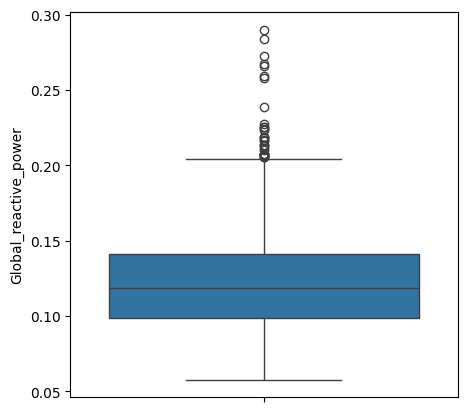

column Voltage has outliers percentage = 9.071428571428571 %
identified outliers [237.23564583333334, 235.3449236111111, 234.94111111111113, 234.7872986111111, 235.21616666666668, 236.87352777777778, 234.6787013888889, 235.58207638888888, 235.1348888888889, 235.71019444444443, 235.03502083333333, 234.4096527777778, 234.5369722222222, 234.9062361111111, 234.8737222222222, 235.79625694444442, 235.22975694444443, 234.72290277777776, 235.7087083333333, 235.69006944444445, 235.61199305555556, 235.26081250000001, 235.86845833333334, 235.9945972222222, 234.94472222222223, 235.34811805555555, 234.6919097222222, 235.48057638888892, 234.81249305555554, 235.5460625, 234.44720138888886, 235.0698888888889, 234.90843750000002, 234.90657638888888, 235.6943472222222, 234.83139583333335, 235.09652777777777, 235.32296527777777, 234.4690277777778, 234.762375, 234.7480694444444, 234.6927638888889, 234.62111458333337, 234.47880555555554, 236.19744444444444, 236.5072361111111, 234.74125694444442, 231.088229

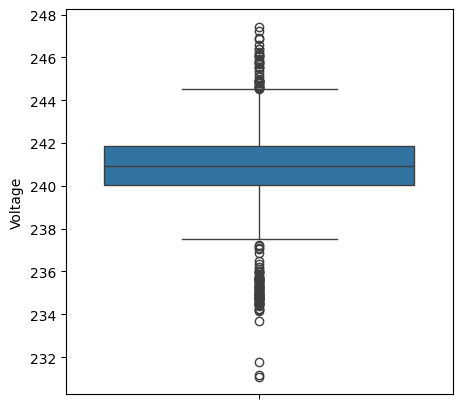

column Global_intensity has outliers percentage = 2.2142857142857144 %
identified outliers [10.199583333333333, 9.478194444444444, 9.453055555555554, 8.971666666666668, 9.348055555555556, 10.190694444444444, 8.733611111111111, 9.133888888888889, 11.815972222222221, 10.565416666666668, 10.526805555555557, 11.238888888888889, 9.168472222222222, 9.880277777777778, 10.121527777777779, 8.703333333333333, 9.717152777777779, 10.264722222222222, 9.191527777777777, 8.618611111111111, 9.030555555555555, 9.56, 8.656319444444446, 9.239166666666666, 8.963194444444444, 10.050416666666667, 9.285416666666666, 9.578888888888889, 9.167638888888888, 9.633194444444444, 9.080972222222222]


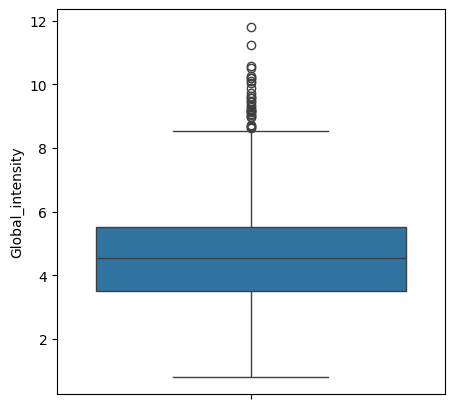

column Sub_metering_1 has outliers percentage = 5.5 %
identified outliers [7806.0, 10346.0, 4746.0, 5071.0, 6107.0, 5727.0, 4810.0, 6564.0, 4630.0, 4629.0, 6575.0, 6575.0, 4581.0, 4683.0, 5420.0, 8060.0, 4985.0, 7091.0, 6651.0, 4840.0, 5042.0, 5201.0, 9356.0, 4751.0, 4588.0, 4836.0, 5594.0, 6505.5, 5918.0, 4670.0, 4925.0, 6283.5, 6286.0, 6279.0, 5153.0, 5045.0, 7076.0, 6950.0, 6471.0, 7549.0, 4705.0, 4673.0, 4801.0, 7893.0, 7597.0, 6301.0, 4791.0, 5268.0, 6440.0, 5811.0, 5649.0, 5096.0, 8278.0, 6822.0, 5341.0, 11224.0, 7253.0, 5420.0, 7498.0, 9583.0, 5490.0, 6202.0, 4941.0, 6012.0, 5694.0, 6774.0, 5184.0, 5284.0, 5905.0, 5499.0, 10932.0, 7609.0, 4922.0, 5740.0, 6029.0, 5344.0, 4855.0]


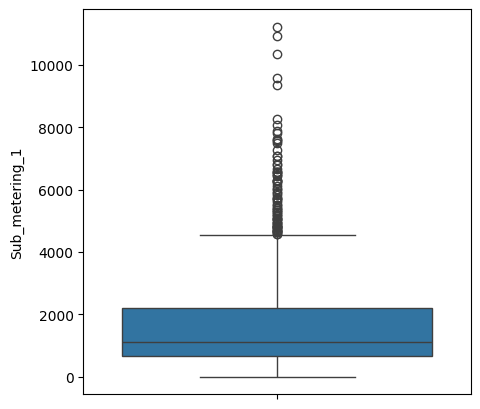

column Sub_metering_2 has outliers percentage = 5.0 %
identified outliers [7938.0, 7597.0, 8177.0, 8003.0, 8711.0, 12109.0, 7369.0, 8527.0, 7707.0, 7529.0, 11440.0, 6451.0, 10265.0, 8912.0, 6965.0, 9452.0, 7457.0, 6622.0, 8022.0, 8255.0, 7494.0, 7871.0, 11020.0, 7941.0, 6915.0, 8554.0, 6883.0, 7640.0, 7803.0, 9797.0, 6651.0, 6657.0, 10713.0, 8811.0, 7682.0, 7358.5, 6802.0, 6754.0, 6500.0, 7042.0, 8010.0, 6214.0, 10409.0, 8829.5, 6479.0, 9189.0, 6701.0, 6949.0, 6575.0, 6961.0, 10477.0, 8576.0, 7288.0, 6670.0, 8080.0, 6454.0, 7655.0, 7052.0, 6403.0, 7544.0, 8423.0, 6636.0, 8142.0, 7645.0, 7895.0, 6313.0, 7966.0, 10218.0, 7541.0, 11193.0]


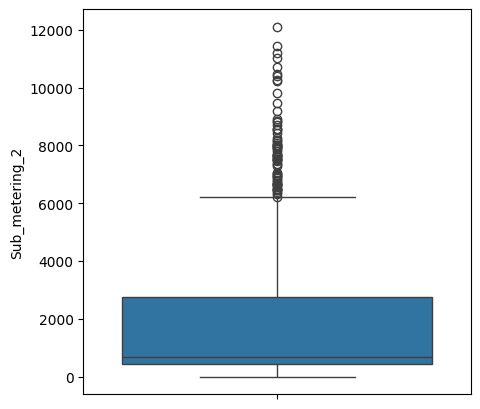

column Sub_metering_3 has outliers percentage = 0.5 %
identified outliers [19509.0, 19409.0, 21536.0, 21130.0, 23743.0, 19764.0, 19769.0]


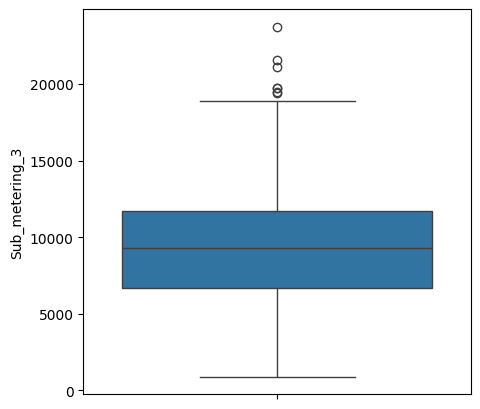

column lag_1 has outliers percentage = 2.2142857142857144 %
identified outliers [2.204438888888889, 2.426525, 2.2634805555555553, 2.2130652777777775, 2.090992361111111, 2.1762027777777777, 2.366154166666667, 2.074898611111111, 2.1475173611111114, 2.7984180555555556, 2.4971805555555555, 2.4800194444444443, 2.6595569444444447, 2.18745, 2.3454305555555557, 2.417108333333333, 2.0614097222222223, 2.317120138888889, 2.4371597222222223, 2.1770430555555556, 2.1618416666666667, 2.290941666666667, 2.177034722222222, 2.105297222222222, 2.366253472222222, 2.231248611111111, 2.064002777777778, 2.304041666666667, 2.1904125, 2.3005916666666666, 2.1746777777777777]


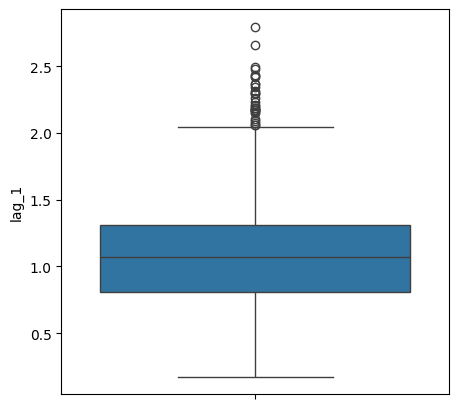

column lag_7 has outliers percentage = 2.2857142857142856 %
identified outliers [3.314851388888889, 2.7320208333333333, 2.204438888888889, 2.426525, 2.2634805555555553, 2.2130652777777775, 2.090992361111111, 2.1762027777777777, 2.366154166666667, 2.074898611111111, 2.1475173611111114, 2.7984180555555556, 2.4971805555555555, 2.4800194444444443, 2.6595569444444447, 2.18745, 2.3454305555555557, 2.417108333333333, 2.317120138888889, 2.4371597222222223, 2.1770430555555556, 2.1618416666666667, 2.290941666666667, 2.177034722222222, 2.105297222222222, 2.366253472222222, 2.231248611111111, 2.304041666666667, 2.1904125, 2.3005916666666666, 2.1746777777777777, 2.0754630872483224]


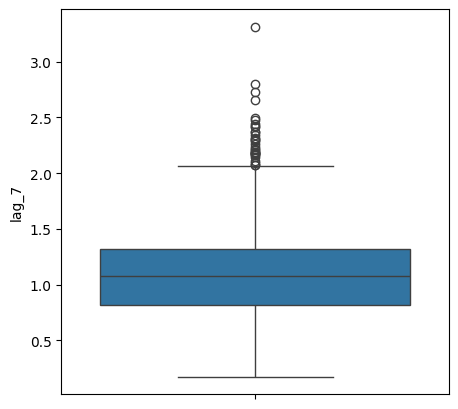

column rolling_mean_7 has outliers percentage = 1.1428571428571428 %
identified outliers [2.0611525793650793, 0.20974623015873015, 0.20208392857142857, 0.19234603174603174, 0.1909281746031746, 0.1895281746031746, 0.1886392857142857, 0.18799146825396826, 0.18599027777777777, 0.18399821428571425, 0.1816708333333333, 0.17997162698412697, 0.1789440476190476, 0.17963333333333334, 0.17967936507936508, 0.18124503968253972]


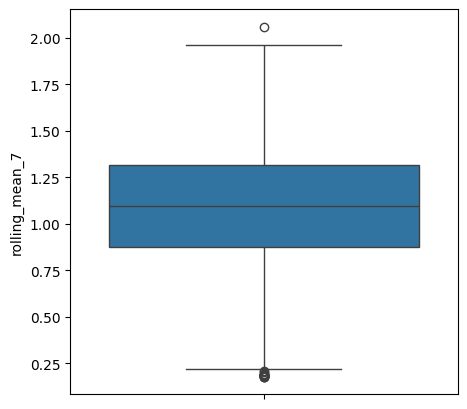

column rolling_std_7 has outliers percentage = 4.857142857142857 %
identified outliers [0.767759273534614, 0.5339408186495244, 0.5707862495319771, 0.5707235053025196, 0.5819412159029694, 0.6575920839462502, 0.6878336339108376, 0.6637461920178186, 0.697944206171424, 0.5995476452214907, 0.572095536061588, 0.5300338168076574, 0.5290752764523294, 0.5314735460930861, 0.5539261236088253, 0.5371716383347773, 0.6116585128409576, 0.6701896249787376, 0.6946332398959775, 0.7376905212102829, 0.7376691671640766, 0.7389985887146252, 0.7425429058895009, 0.5676404834156311, 0.5626176314895703, 0.5489137118251393, 0.5310242881680594, 0.536040218044662, 0.5508245661113205, 0.5422874348991779, 0.5316019718946372, 0.5628466839612404, 0.6205668375904089, 0.7882830385806069, 0.7795443464938585, 0.845076196353554, 0.7521741845037403, 0.7332956531479563, 0.6243108184165151, 0.5992894145817441, 0.6283600087669171, 0.5581802607861436, 0.5750053533794868, 0.5547934063795436, 0.5497792307665077, 0.544224433703399

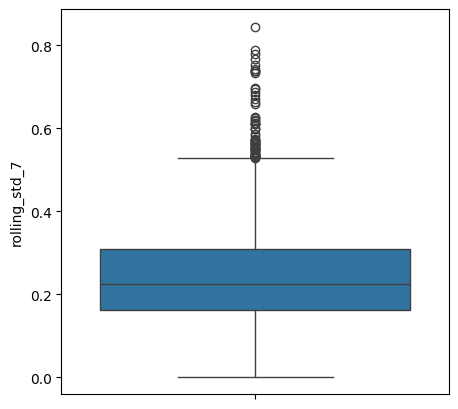

In [ ]:
for k,v in cont_numerical_feat.items():
  q1=v.quantile(0.25)
  q3=v.quantile(0.75)
  irq=q3-q1
  v_out = v[ (v >= q3+irq*1.5)  |    (v <= q1-irq*1.5)]
  perc= np.shape(v_out)[0]*100/np.shape(df)[0]
  print(f'column {k} has outliers percentage = {perc} %')
  print(f'identified outliers {v_out.tolist()}')
  plt.figure(figsize=(5,5))
  sns.boxplot( y= k , data=df)
  plt.show()

## **3.4 visualization for categorical features**

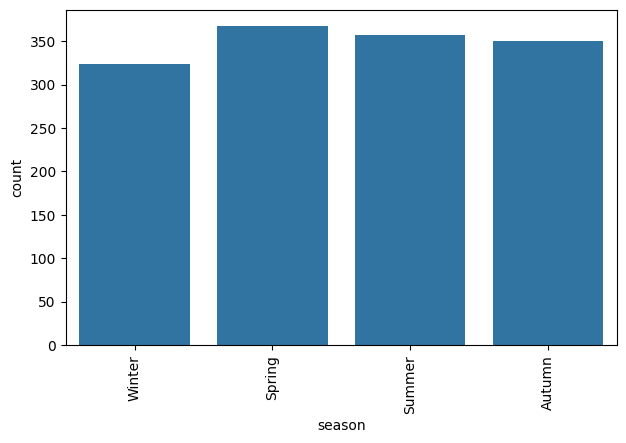

In [ ]:
fig = plt.figure(figsize=(12,8))
for index in range(len(categorical_feat.columns)):
    plt.subplot(2,2,index+1)
    sns.countplot(x=categorical_feat.iloc[:,index], data=categorical_feat.dropna())
    plt.xticks(rotation=90)
fig.tight_layout(pad=1.0)

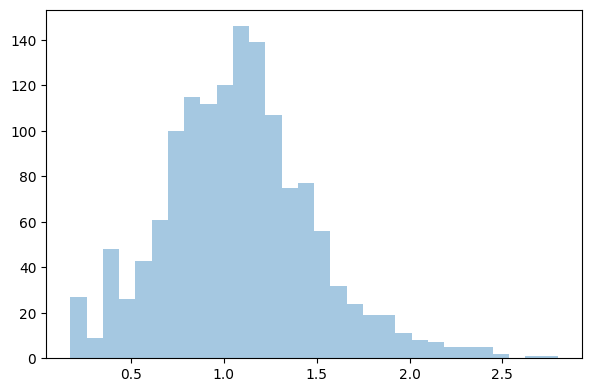

In [ ]:
fig = plt.figure(figsize=(6,4))
sns.distplot(y.dropna(), kde=False)
fig.tight_layout(pad=1.0)

## **3.5 relation between numerical features & target**

<Axes: >

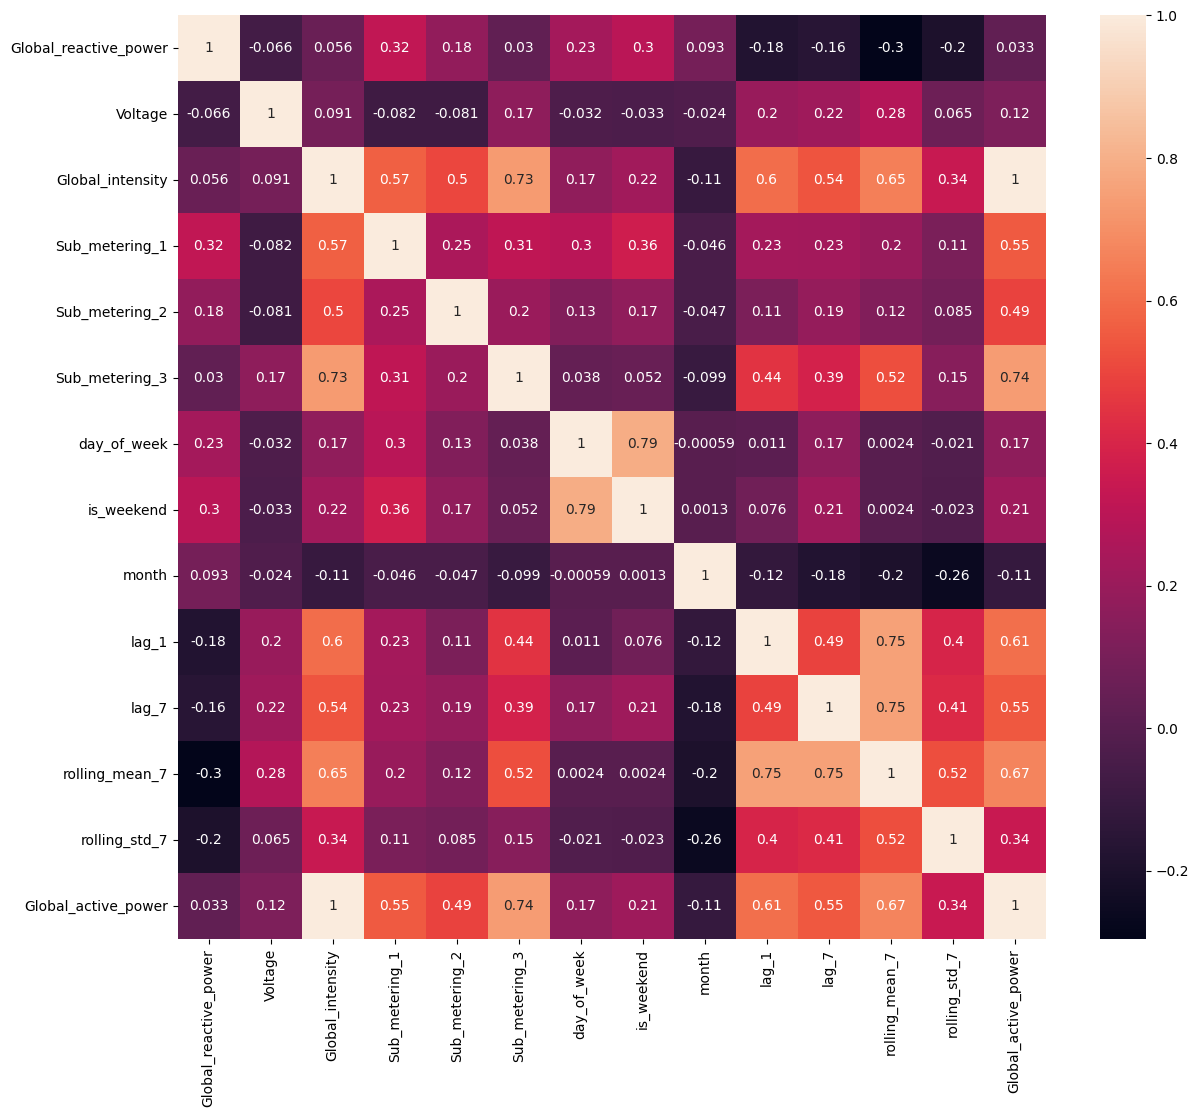

In [ ]:
categ=categorical_feat.columns
num_tar=df.drop(columns=categ , axis=1)
plt.figure(figsize=(14,12))
correlation = num_tar.corr()
sns.heatmap(correlation, annot=True)

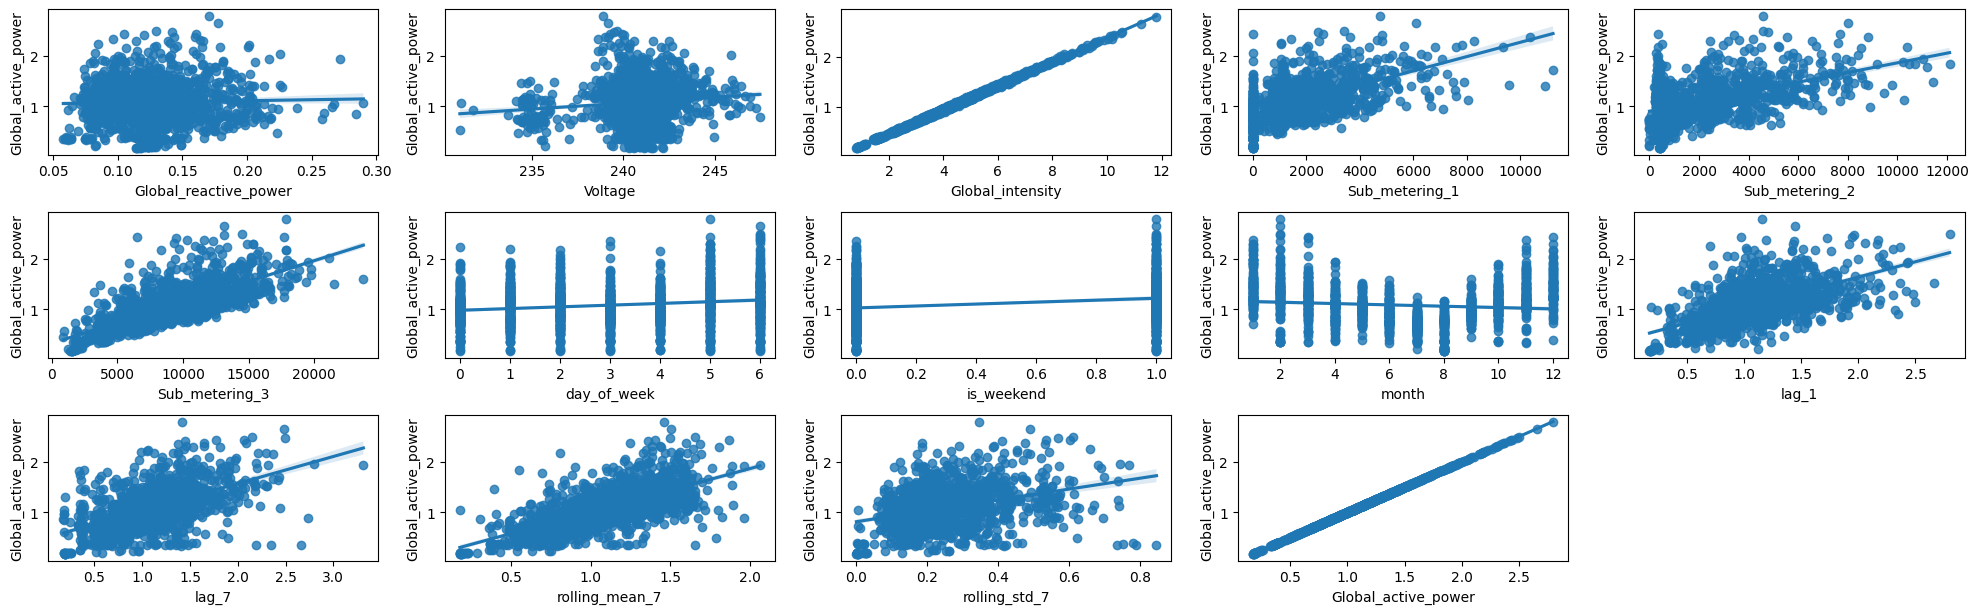

In [ ]:
fig = plt.figure(figsize=(20,20))
for index in range(len(num_tar.columns)):
    plt.subplot(10,5,index+1)
    sns.regplot(x=num_tar.iloc[:,index], y='Global_active_power', data=num_tar)
fig.tight_layout(pad=1.0)

## **3.6 Global_active_power with respect to seasonal**

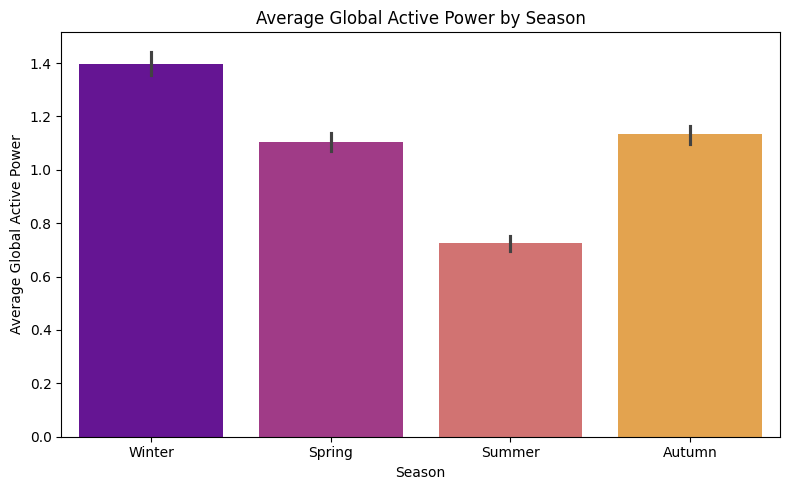

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='season',
    y='Global_active_power',
    palette='plasma'
)

plt.title('Average Global Active Power by Season')
plt.xlabel('Season')
plt.ylabel('Average Global Active Power')
plt.tight_layout()
plt.show()

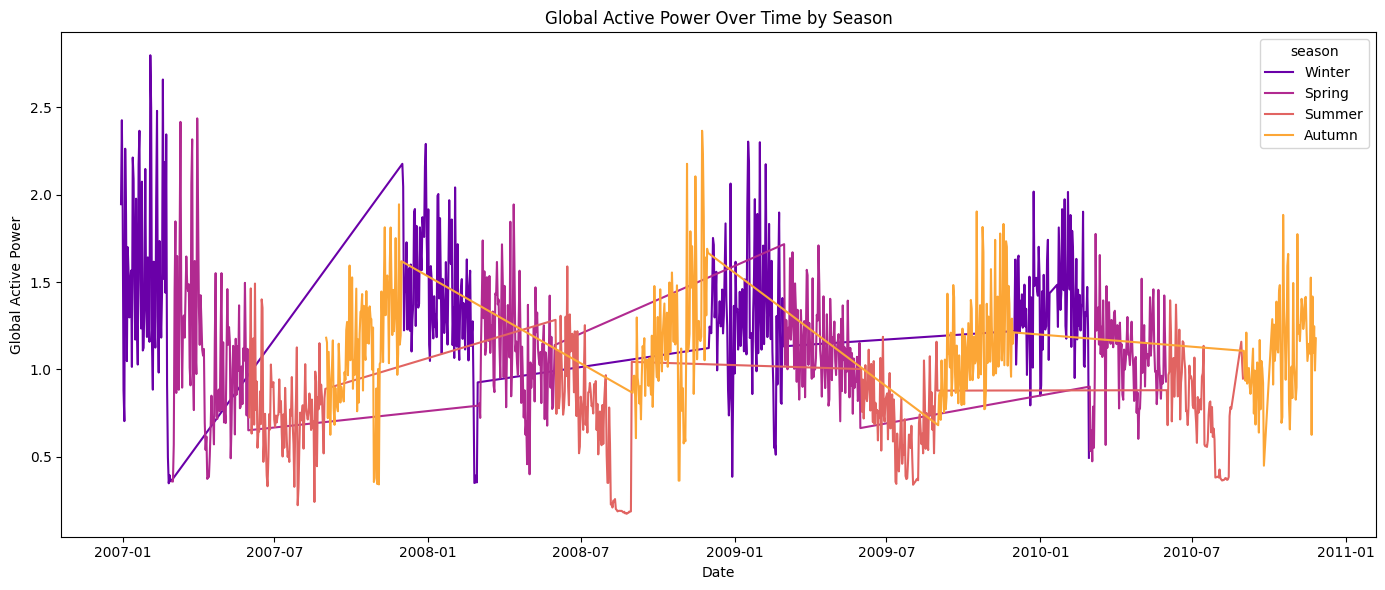

In [ ]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=df,
    x=df.index,
    y='Global_active_power',
    hue='season',
    palette='plasma'
)

plt.title('Global Active Power Over Time by Season')
plt.xlabel('Date')
plt.ylabel('Global Active Power')

plt.tight_layout()
plt.show()

## **3.7 Weekends vs Weekdays**

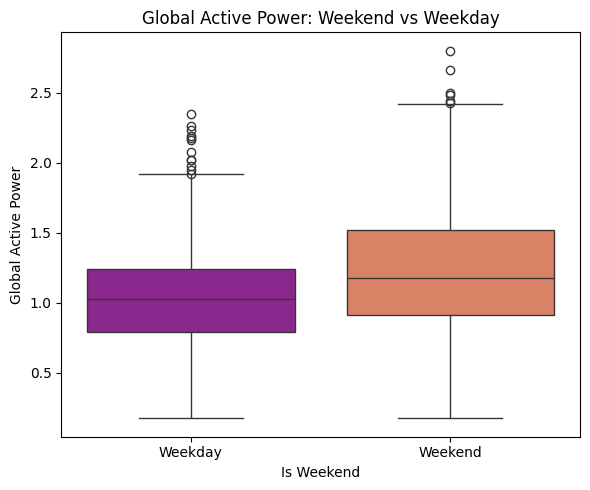

In [ ]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df,
    x='is_weekend',
    y='Global_active_power',
    palette='plasma'
)

plt.title('Global Active Power: Weekend vs Weekday')
plt.xlabel('Is Weekend')
plt.ylabel('Global Active Power')

plt.xticks([0,1], ['Weekday', 'Weekend'])

plt.tight_layout()
plt.show()

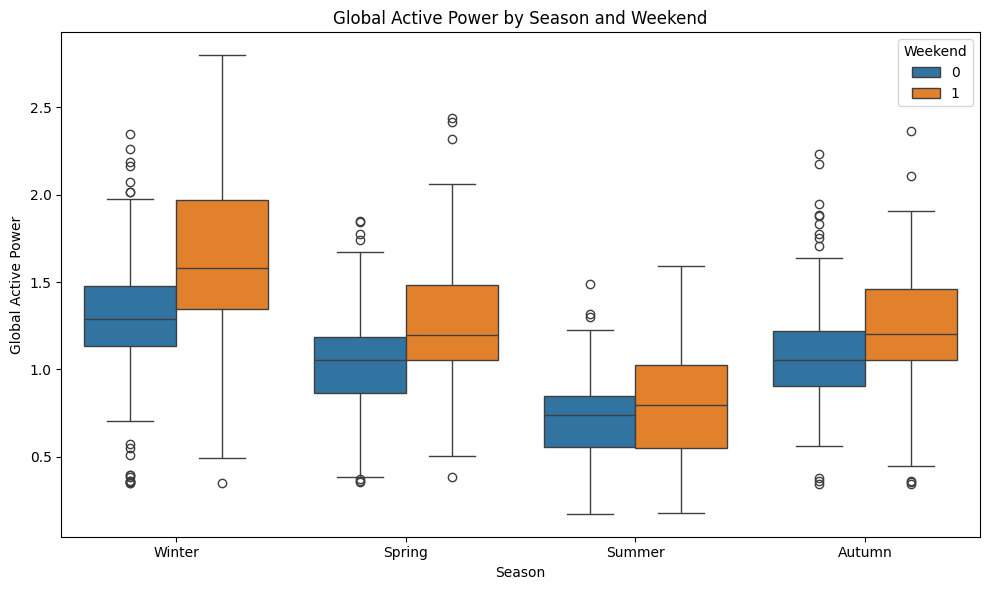

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='season',
    y='Global_active_power',
    hue='is_weekend'
)

plt.title('Global Active Power by Season and Weekend')
plt.xlabel('Season')
plt.ylabel('Global Active Power')

plt.legend(title='Weekend')

plt.tight_layout()
plt.show()

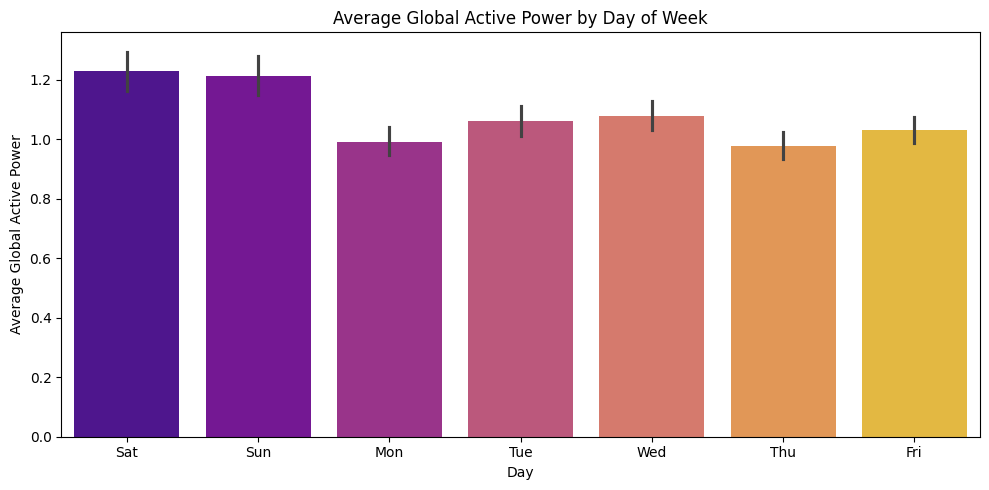

In [ ]:
day_names = {
    0:'Mon',
    1:'Tue',
    2:'Wed',
    3:'Thu',
    4:'Fri',
    5:'Sat',
    6:'Sun'
}

df['day_name'] = df['day_of_week'].map(day_names)

plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x='day_name',
    y='Global_active_power',
    palette='plasma'
)

plt.title('Average Global Active Power by Day of Week')
plt.xlabel('Day')
plt.ylabel('Average Global Active Power')

plt.tight_layout()
plt.show()

## **3.8 Global_active_power with respect to Months**

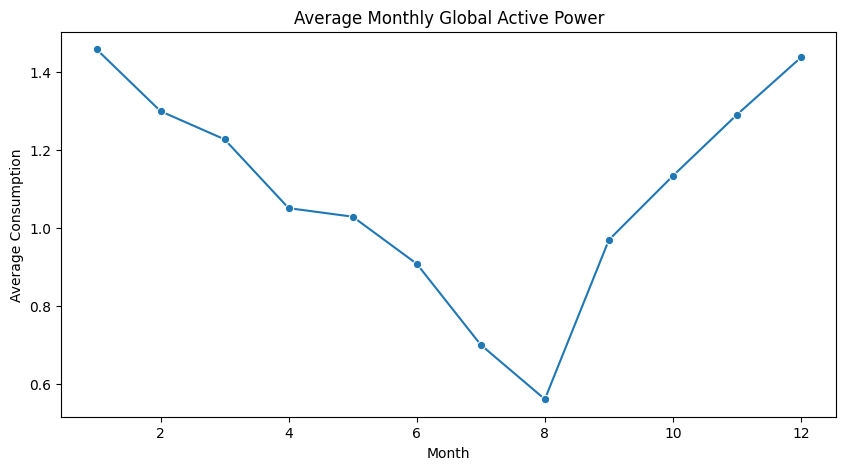

In [ ]:
monthly_avg = (
    df
    .groupby('month')['Global_active_power']
    .mean()
)

plt.figure(figsize=(10,5))

sns.lineplot(
    x=monthly_avg.index,
    y=monthly_avg.values,
    marker='o'
)

plt.title('Average Monthly Global Active Power')

plt.xlabel('Month')
plt.ylabel('Average Consumption')

plt.show()

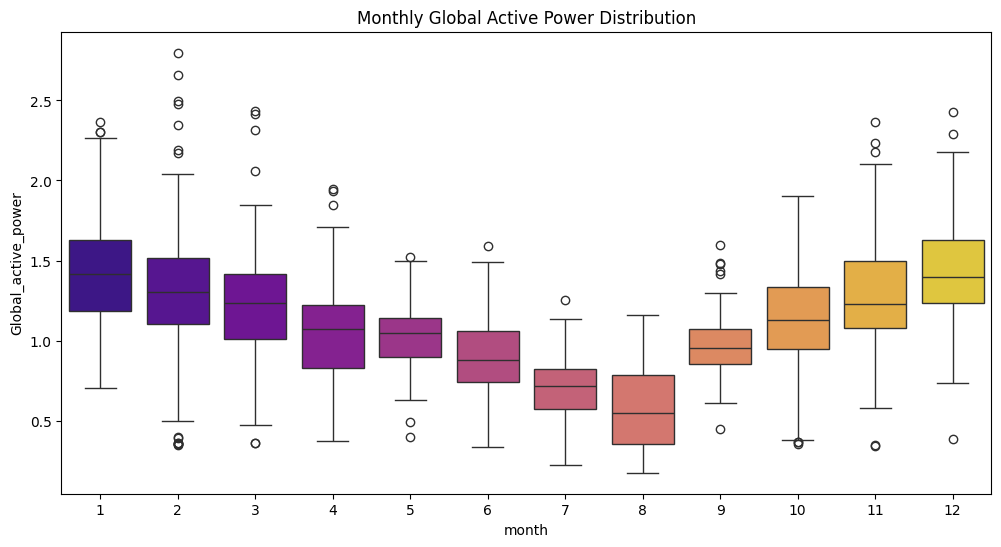

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='month',
    y='Global_active_power',
    palette='plasma'
)

plt.title('Monthly Global Active Power Distribution')

plt.show()

# ***4.MODELING***

In [ ]:
df.head()

,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,day_of_week,is_weekend,month,season,lag_1,lag_7,rolling_mean_7,rolling_std_7,Global_active_power,day_name
datetime,,,,,,,,,,,,,,,,
2006-12-30,0.22,240.54,8.32,3147.00,7938.00,12515.00,5,1,12,Winter,2.20,3.31,2.06,0.77,1.95,Sat
2006-12-31,0.10,239.90,10.20,0.00,347.00,6502.00,6,1,12,Winter,1.95,1.77,1.87,0.53,2.43,Sun
2007-01-01,0.10,240.13,7.92,0.00,352.00,5880.00,0,0,1,Winter,2.43,1.90,1.96,0.57,1.91,Mon
2007-01-02,0.13,241.94,3.71,0.00,348.00,6562.00,1,0,1,Winter,1.91,2.73,1.96,0.57,0.88,Tue
2007-01-03,0.14,243.56,3.01,0.00,344.00,4765.00,2,0,1,Winter,0.88,1.06,1.70,0.58,0.70,Wed


In [ ]:
month_names = {
    1: 'January',
    2: 'February',
    3: 'March',
    4: 'April',
    5: 'May',
    6: 'June',
    7: 'July',
    8: 'August',
    9: 'September',
    10: 'October',
    11: 'November',
    12: 'December'
}

df['month'] = df['month'].map(month_names)
df.drop(['day_of_week'],axis=1,inplace=True)
df=df[['Global_reactive_power', 'Voltage', 'Global_intensity',
       'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'day_name',
       'is_weekend', 'month', 'season', 'lag_1', 'lag_7', 'rolling_mean_7',
       'rolling_std_7', 'Global_active_power']]

df.head()

,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,day_name,is_weekend,month,season,lag_1,lag_7,rolling_mean_7,rolling_std_7,Global_active_power
datetime,,,,,,,,,,,,,,,
2006-12-30,0.22,240.54,8.32,3147.00,7938.00,12515.00,Sat,1,December,Winter,2.20,3.31,2.06,0.77,1.95
2006-12-31,0.10,239.90,10.20,0.00,347.00,6502.00,Sun,1,December,Winter,1.95,1.77,1.87,0.53,2.43
2007-01-01,0.10,240.13,7.92,0.00,352.00,5880.00,Mon,0,January,Winter,2.43,1.90,1.96,0.57,1.91
2007-01-02,0.13,241.94,3.71,0.00,348.00,6562.00,Tue,0,January,Winter,1.91,2.73,1.96,0.57,0.88
2007-01-03,0.14,243.56,3.01,0.00,344.00,4765.00,Wed,0,January,Winter,0.88,1.06,1.70,0.58,0.70


In [ ]:
df.columns

Index(['Global_reactive_power', 'Voltage', 'Global_intensity',
       'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'day_name',
       'is_weekend', 'month', 'season', 'lag_1', 'lag_7', 'rolling_mean_7',
       'rolling_std_7', 'Global_active_power'],
      dtype='object')

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split,GridSearchCV,GridSearchCV,TimeSeriesSplit
from sklearn.preprocessing import StandardScaler,RobustScaler,OneHotEncoder
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
from sklearn.compose import ColumnTransformer


In [ ]:
df = pd.get_dummies(
    df,
    columns=['month', 'day_name', 'season'],
    drop_first=True
)

## **4.1 train test split**

In [ ]:
train = df[df.index.year < 2010].copy()
test  = df[df.index.year == 2010].copy()
x_train=train.drop(columns=['Global_active_power'])
y_train=train['Global_active_power']
x_test=test.drop(columns=['Global_active_power'])
y_test=test['Global_active_power']

In [ ]:
print(x_train.shape)
print(x_test.shape)

(1098, 31)
(302, 31)


In [ ]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1098 entries, 2006-12-30 to 2009-12-31
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Global_reactive_power  1098 non-null   float64
 1   Voltage                1098 non-null   float64
 2   Global_intensity       1098 non-null   float64
 3   Sub_metering_1         1098 non-null   float64
 4   Sub_metering_2         1098 non-null   float64
 5   Sub_metering_3         1098 non-null   float64
 6   is_weekend             1098 non-null   int64  
 7   lag_1                  1098 non-null   float64
 8   lag_7                  1098 non-null   float64
 9   rolling_mean_7         1098 non-null   float64
 10  rolling_std_7          1098 non-null   float64
 11  month_August           1098 non-null   bool   
 12  month_December         1098 non-null   bool   
 13  month_February         1098 non-null   bool   
 14  month_January          1098 non-null  

In [ ]:
num_col=[col for col in x_train.columns if x_train[col].dtypes != 'bool']

In [ ]:
x_train.columns

Index(['Global_reactive_power', 'Voltage', 'Global_intensity',
       'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'is_weekend',
       'lag_1', 'lag_7', 'rolling_mean_7', 'rolling_std_7', 'month_August',
       'month_December', 'month_February', 'month_January', 'month_July',
       'month_June', 'month_March', 'month_May', 'month_November',
       'month_October', 'month_September', 'day_name_Mon', 'day_name_Sat',
       'day_name_Sun', 'day_name_Thu', 'day_name_Tue', 'day_name_Wed',
       'season_Spring', 'season_Summer', 'season_Winter'],
      dtype='object')

## **4.2 Pipeline preparation**

In [ ]:
num_transf=Pipeline(steps=[
    ('scalar',RobustScaler())
])

preprocessor=ColumnTransformer(transformers=[
    ('num',num_transf,num_col)
])

LR_Model=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('regressor',LinearRegression())
])

DT_pipeline=Pipeline(steps=[
    ('regressor',DecisionTreeRegressor(random_state=43))
])

DT_pg=[{
    'regressor__max_depth': [3, 5, 7, 10, None],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4]
}]
DT_gs=GridSearchCV(DT_pipeline,param_grid=DT_pg,cv=TimeSeriesSplit(n_splits=5),scoring='r2')

RF_pipeline=Pipeline(steps=[
    ('regressor',RandomForestRegressor(random_state=43))
])

RF_pg=[{
    'regressor__n_estimators': [100, 200, 300],
    'regressor__max_depth': [None, 10, 20, 30],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4],
}]

RF_gs=GridSearchCV(RF_pipeline,param_grid=RF_pg,cv=TimeSeriesSplit(n_splits=5),scoring='r2')

GB_pipeline=Pipeline(steps=[
    ('regressor',GradientBoostingRegressor(random_state=43))
])

GB_pg=[{
    'regressor__n_estimators': [100, 200],
    'regressor__learning_rate': [0.05, 0.1, 0.2],
    'regressor__max_depth': [3, 5, 7],
    'regressor__min_samples_split': [2, 5],
    'regressor__min_samples_leaf': [1, 2],
    'regressor__subsample': [0.8, 1.0]
}]

GB_gs=GridSearchCV(GB_pipeline,param_grid=GB_pg,cv=TimeSeriesSplit(n_splits=5),scoring='r2')

## **4.3 Fitting grid search**

In [ ]:
# DT_gs.fit(x_train,y_train)
# RF_gs.fit(x_train,y_train)
# GB_gs.fit(x_train,y_train)

In [ ]:
# print(DT_gs.best_params_)
# print(RF_gs.best_params_)
# print(GB_gs.best_params_)

In [ ]:
# print(DT_gs.best_estimator_)
# print(RF_gs.best_estimator_)
# print(GB_gs.best_estimator_)

In [ ]:
DT_Model=Pipeline(steps=[('regressor',
                 DecisionTreeRegressor(max_depth=10, min_samples_leaf=2,
                                       min_samples_split=5, random_state=43))])
RF_Model=Pipeline(steps=[('regressor',
                 RandomForestRegressor(max_depth=10, n_estimators=300,
                                       random_state=43))])
GB_Model=Pipeline(steps=[('regressor',
                 GradientBoostingRegressor(min_samples_leaf=2,
                                           min_samples_split=5,
                                           n_estimators=200, random_state=43,
                                           subsample=0.8))])

## **4.4 Model fitting**

In [ ]:
LR_Model.fit(x_train,y_train)
DT_Model.fit(x_train,y_train)
RF_Model.fit(x_train,y_train)
GB_Model.fit(x_train,y_train)

Pipeline(steps=[('regressor',
                 GradientBoostingRegressor(min_samples_leaf=2,
                                           min_samples_split=5,
                                           n_estimators=200, random_state=43,
                                           subsample=0.8))])

## **4.5 Apply model prediction**

In [ ]:
LR_pred=LR_Model.predict(x_test)
DT_pred=DT_Model.predict(x_test)
RF_pred=RF_Model.predict(x_test)
GB_pred=GB_Model.predict(x_test)

## **4.6 Model evaluation**

In [ ]:
def evaluate_model(model_name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    return pd.DataFrame({
        'Model': [model_name],
        'R2': [r2],
        'MAE': [mae],
        'RMSE': [rmse]
    })


lr_results = evaluate_model('Linear Regression', y_test, LR_pred)
dt_results = evaluate_model('Decision Tree', y_test, DT_pred)
rf_results = evaluate_model('Random Forest', y_test, RF_pred)
gb_results = evaluate_model('Gradient Boosting', y_test, GB_pred)


final_results = pd.concat([lr_results, dt_results, rf_results, gb_results], axis=0)
final_results = final_results.sort_values(by='R2', ascending=False).reset_index(drop=True)

final_results

,Model,R2,MAE,RMSE
0,Linear Regression,1.00,0.01,0.01
1,Gradient Boosting,1.00,0.01,0.01
2,Random Forest,1.00,0.01,0.01
3,Decision Tree,1.00,0.02,0.02


## **4.7 Overfitting check for the best model "Linear Regression"**

Train R2: 0.9995402353530457
Test R2: 0.9994717901542473


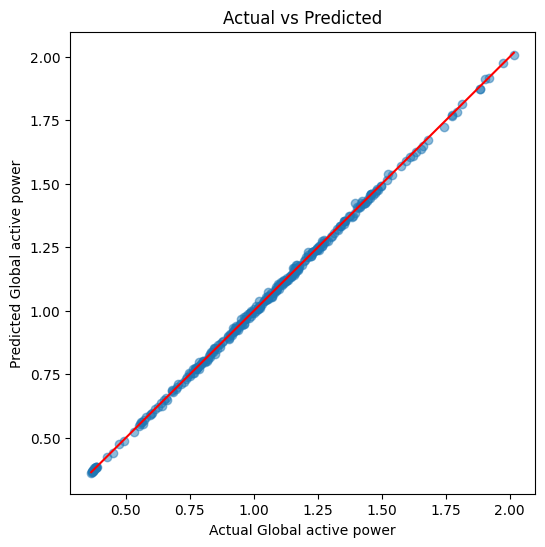

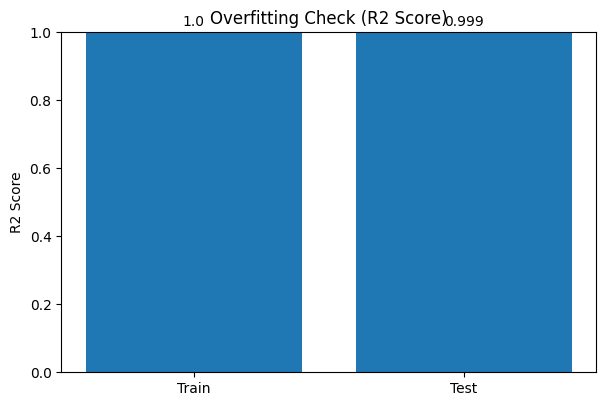

In [ ]:
y_train_orginal=y_train


LR_train_pred = LR_Model.predict(x_train)
train_r2 = r2_score(y_train_orginal, LR_train_pred)


test_r2 = r2_score(y_test, LR_pred)


print("Train R2:", train_r2)
print("Test R2:", test_r2)



plt.figure(figsize=(6,6))

plt.scatter(y_test, LR_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel('Actual Global active power')
plt.ylabel('Predicted Global active power')
plt.title('Actual vs Predicted')

plt.show()



labels = ['Train', 'Test']
scores = [train_r2, test_r2]

plt.figure(figsize=(6,4))
plt.bar(labels, scores)
plt.title('Overfitting Check (R2 Score)')
plt.ylabel('R2 Score')
plt.ylim(0,1)
plt.tight_layout(pad=0.5)
for i, v in enumerate(scores):
    plt.text(i, v + 0.02, round(v, 3), ha='center')

plt.show()